# Mô hình và đồ thị nhân quả — toàn bộ quy trình, từ dữ liệu thô đến phán quyết

Notebook này gom **mọi thứ liên quan tới mô hình và đồ thị nhân quả** của dự án vào một chỗ: dữ liệu, cách
**xây dựng** đồ thị, cách **huấn luyện** từng cơ chế, cách suy luận can thiệp, và cách đánh giá. Mỗi bước có lời
giải thích rồi code **chạy lại chính module trong `src/`** trên file thật — không chép số tay.

**Cách chạy:** mở trong IDE, chọn kernel **`.venv`** (`.venv\Scripts\python.exe`), rồi *Run All* (≈ 1 phút).
Notebook chỉ **đọc** dữ liệu, không ghi đè file nào, không chạy tải. Đừng chạy khi đang đo ramp.

## Dự án có HAI nhánh mô hình — đừng lẫn

| | **Phần A — Global Causal DAG** | **Phần B — Bộ dự đoán khả thi** |
|---|---|---|
| Code | `src/agents/capacity_agent.py` + `src/scm/*` | `src/scm/feasibility_predictor.py` + `src/agents/feasibility_agent.py` |
| Câu hỏi | Tăng workload ở gateway thêm δ% thì CPU/mem/độ trễ **mọi node** đổi bao nhiêu? | Thêm tính năng **chưa tồn tại** thì còn đạt SLO ở tải L không, node nào nghẽn, **điểm gãy** ở đâu? |
| Dữ liệu huấn luyện | RCAEval **RE2-SS** (đoạn bình thường trước khi tiêm lỗi) | `SS-TRAIN` — testbed Sock Shop tự dựng, quét tải |
| Đồ thị | 28 node (workload/cpu/mem/latency × 7 service), cạnh cấu trúc + cạnh **học** | Chuỗi đơn giản L → W_s → CPU_s → u_s, cạnh theo chuỗi gọi |
| Cơ chế | DoWhy GCM: tuyến tính hệ số không âm + hồi quy hàng đợi | NNLS `CPU = α + β·W` + ngưỡng u* |
| Đánh giá trong bài | RQ1–RQ4 | RQ5 (tiến cứu, n = 10) |

| Mục | Nội dung |
|---|---|
| **A1** | Dữ liệu RE2-SS và *cổng tín hiệu* |
| **A2** | Xây đồ thị: đồ thị phụ thuộc → bảng mẫu cạnh → cạnh cấu trúc |
| **A3** | Học cạnh: ứng viên → chấm held-out → knee-point → kiểm OOD |
| **A4** | Gán cơ chế và huấn luyện DAG |
| **A5** | Đường nhanh: 21 mô hình hai biến và giao thức OOD 67/33 |
| **A6** | Suy luận can thiệp: forward tất định so với Monte Carlo |
| **A7** | Bao an toàn chứng nhận (Mệnh đề 2) và can thiệp đồng thời |
| **A8** | Độ ổn định, ảnh hưởng người dùng, biên dự phòng |
| **B1–B8** | Bộ dự đoán khả thi: bài toán → dữ liệu → đồ thị → **huấn luyện** → đóng băng → dự đoán → tiến cứu → chẩn đoán |
| **C** | Hạn chế đã biết của cả hai nhánh và hướng cải tiến |

In [1]:
import glob, json, os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

ROOT = Path.cwd()
while not (ROOT / 'src').exists():          # notebook nam trong notebooks/ -> leo len goc repo
    ROOT = ROOT.parent
# Duong dan phai TU TIM: tu lan tach hai bai, experiments/ da chuyen sang
# papers/<bai>/experiments/. Ghi tay duong dan la nguon muc rua -- chinh loi do
# da lam ca notebook nay vo 26/91 o (mot loi import trong o nay keo theo 25 o sau).
sys.path[:0] = [str(ROOT / 'src' / 'scm'), str(ROOT / 'src' / 'agents'), str(ROOT / 'src')]
sys.path[3:3] = [str(p) for p in sorted(ROOT.glob('papers/*/experiments/*'))
                 if p.is_dir() and p.name != 'archive' and any(p.glob('*.py'))]
sys.path[3:3] = [str(p) for p in sorted(ROOT.glob('experiments/*')) if p.is_dir()]
import contextlib, io, warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('TQDM_DISABLE', '1')

@contextlib.contextmanager
def quiet():
    '''an log dai cua dowhy/agent de notebook de doc'''
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        yield

import feasibility_predictor as FP                  # bo du doan (nguon su that duy nhat)
from request_router import SOCKSHOP_CALL_CHAINS     # taxonomy archetype
import load_sweep_collect as HARNESS                # bang FEATURES cua harness (anchor = Delta)

FROZEN = ROOT / 'data' / 'processed' / 'frozen'
RAW = ROOT / 'data' / 'raw'

# `data/manifest.json` -- ban do du lieu, sinh boi
# papers/p1_du_phong/experiments/collect/sinh_manifest_du_lieu.py
# Dung no de GIAI TEN bo du lieu thay vi ghi tay duong dan: cac bo long 2 cap
# (SS-TRAIN, SS-LIMITS*, SS-VERIFY) va 3 cap (SS-PROSP2 -> SS-PROSP2/SS-PROSP2).
# Ghi tay la nguon loi that: truoc khi sua, notebook nay tro `RAW/'SS-PROSP2/ramp_login_x1'`
# -- thieu mot cap -- va 4 o vo vi FileNotFoundError.
try:
    MANIFEST = json.load(open(ROOT / 'data' / 'manifest.json', encoding='utf-8'))['bo_du_lieu']
except FileNotFoundError:
    MANIFEST = {}

def bo(ten):
    '''Thu muc THAT chua cac ramp_* cua mot bo du lieu, giai qua manifest.'''
    if ten in MANIFEST:
        return ROOT / MANIFEST[ten]['duong_dan']
    for k, v in MANIFEST.items():                     # khop theo doan cuoi (SS-PROSP2 -> SS-PROSP2/SS-PROSP2)
        if k.split('/')[-1] == ten:
            return ROOT / v['duong_dan']
    d = RAW / ten                                     # khong co manifest -> do bang cau truc
    return d if list(d.glob('ramp_*')) else next((q for q in sorted(d.glob('*')) if list(q.glob('ramp_*'))), d)
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})
try:
    display
except NameError:            # chay ngoai Jupyter (kiem thu) -> in thuong
    display = print
print('goc repo:', ROOT)

goc repo: /Users/ngkky/NCKH/NCKH


---
# PHẦN 0 — Làm sạch dữ liệu tự đo (`measured_data.py`)

Hai nhánh A và B sắp dùng **chung** nền dữ liệu tự đo, nên việc đầu tiên là một **cửa duy nhất** vào
`data/raw/SS-*`: `src/scm/measured_data.py`. Module chỉ **đọc và lọc** — không ghi, không sửa, không xoá gì
trong `data/raw` (dữ liệu thô là bất biến) — và mọi phép loại bỏ đều trả kèm **lý do có xuất xứ tệp:dòng**,
để người đọc báo cáo kiểm lại được từng quyết định.

## 0.1 Chín khiếm khuyết — đều là số đã đo, không phải lo xa

| # | Khiếm khuyết | Số đo |
|---|---|---|
| 1 | **Hai kiểu lồng thư mục**: `SS-TRAIN`/`SS-LIMITS*`/`SS-VERIFY` lồng 2 cấp, `SS-PROSP2` lồng 3 cấp | `load_multi_service_data('data/raw/SS-PROSP2')` → **`None`**; `data_contract_check.py` glob `*/*/` cũng mù |
| 2 | **Vai là thuộc tính của HÀNG, không phải của thư mục** | `SS-LIMITS` chứa 836 dòng base + 1 970 dòng có tính năng trong cùng một gốc |
| 3 | Hàng **warm-up** | 36–38% mọi gốc có `gt_step_warm == 1`; hợp đồng tính trên 60% cuối mỗi bậc |
| 4 | Hàng **sau vi phạm SLO** | 12%–100% tuỳ gốc; `SS-LIMITS-C1` có tỉ lệ **1,000** — mọi hàng |
| 5 | **Cấu hình trần không hợp lệ** | `limits.json:_status` đánh dấu C1, C2 `_INVALID`: CFS throttling, SLO vỡ ở u ≈ 20–45% thay vì ~88% |
| 6 | **Gốc không nhãn** | `SS-CALIBRATION`: không cột `gt_*` nào, có cột lạ `load_level` |
| 7 | **Gốc rỗng** | `SS-LOADSWEEP`: 0 run, còn một tệp `collector_*.csv` rơi |
| 8 | **Dị biệt giữa phiên thu** | hệ số góc `cpu~workload`: `orders` lệch 2,3×, `shipping` 8× qua 10 phiên `ramp_base` |
| 9 | **Tập KHOÁ** | `data_contract_check.py:38`: `track`, `review` — không dùng khi chỉnh mô hình |

Đã kiểm và **sạch**: không có bão hoà host ở bất kỳ gốc nào (`vm_cpu_util` lớn nhất 0,48).

## 0.2 Một xung đột phải biết trước khi chọn tập train

`data_contract_check.py:96-103` định nghĩa `role=train` là **base + KHÔNG trần + không bậc vi phạm SLO**.
Theo đúng định nghĩa đó thì **chỉ `SS-TRAIN` (608 dòng, *một* phiên) là tập train hợp lệ**, còn toàn bộ 31 run
`ramp_base` — thứ duy nhất chứa node chạm trần (front-end u ≈ 0,94) — bị loại khỏi vai train.

Đây là một đánh đổi thật, không phải lỗi. Nên module cho **ba** `purpose` thay vì một, và bắt người gọi
chọn tường minh:

| `purpose` | Nghĩa | Dùng khi |
|---|---|---|
| `train` | hợp đồng nghiêm: base, `limits=none`, chưa bão hoà | muốn số liệu không ai bắt lỗi được về quy trình |
| `baseline` | base dưới trần **hợp lệ** (`none` hoặc `RE2`), chỉ hàng ổn định | cần cả vùng gần trần — **phải khai báo là đã nới hợp đồng** |
| `eval` | run **có** tính năng = tập đánh giá; tập KHOÁ bị loại | đo độ chính xác dự đoán |

In [2]:
import measured_data as MD

audit = MD.audit()
print(f'khám phá được {len(audit)} run, {int(audit.n.sum()):,} dòng trong data/raw/SS-*')
print(f"(so sánh: data_contract_check.py chỉ thấy "
      f"{int(audit[audit.batch == ''].n.sum()):,} dòng — phần lồng 3 cấp của SS-PROSP2 nằm ngoài glob của nó)\n")

_, rep = MD.load('baseline')
display(MD.summarize(rep))

khám phá được 203 run, 17,290 dòng trong data/raw/SS-*
(so sánh: data_contract_check.py chỉ thấy 6,697 dòng — phần lồng 3 cấp của SS-PROSP2 nằm ngoài glob của nó)



,root,why,runs,dong
0,SS-CALIBRATION,unlabelled,5,53
1,SS-LIMITS,(DUNG),5,836
2,SS-LIMITS,has_feature,16,1970
3,SS-LIMITS-C1,invalid_limits,3,99
4,SS-LIMITS-C2,invalid_limits,1,113
5,SS-LIMITS-CLEAN,(DUNG),1,156
6,SS-LIMITS-CLEAN,has_feature,12,1161
7,SS-LIMITS-INDEP,(DUNG),2,324
8,SS-LIMITS-INDEP,has_feature,14,1072
9,SS-LIMITS-PROSP,(DUNG),1,115


**Đọc bảng:** `(DÙNG)` là số run/dòng đi vào `purpose='baseline'`. Mỗi lý do loại bỏ tra được sang
`MD.WHY[...]` để lấy xuất xứ đầy đủ. Ba dòng đáng chú ý: `invalid_limits` (C1+C2, 212 dòng — bỏ theo
`limits.json:_status`), `unlabelled` (`SS-CALIBRATION`, 53 dòng), `empty_root` (`SS-LOADSWEEP`).

Ô dưới nạp cả ba `purpose` rồi trả lời câu hỏi duy nhất đáng hỏi về một lớp làm sạch: **nó có đổi gì không?**

In [3]:
import numpy as np, pandas as pd, glob

def r2_slope(d, s):
    x, y = d[f'{s}_workload'].values, d[f'{s}_cpu'].values
    m = np.isfinite(x) & np.isfinite(y); x, y = x[m], y[m]
    if len(x) < 10 or x.std() == 0:
        return np.nan, np.nan
    c = np.polyfit(x, y, 1); p = np.polyval(c, x); st = ((y - y.mean()) ** 2).sum()
    return (1 - ((y - p) ** 2).sum() / st if st > 0 else np.nan), c[0]

d_strict, _ = MD.load('train')                          # hợp đồng nghiêm
d_clean,  _ = MD.load('baseline')                       # sạch + chỉ hàng ổn định
d_eval,   _ = MD.load('eval')                           # tập đánh giá
# THÔ = mọi run base, KHÔNG bỏ C1/C2/CALIBRATION, KHÔNG lọc hàng warm/violated
#       (đúng cách "trỏ thư mục rồi đọc hết" mà lớp làm sạch thay thế)
d_raw = pd.concat([pd.read_csv(f'{r.path}/simple_metrics.csv')
                   for r in audit.itertuples() if r.n and r.feature == 'base'], ignore_index=True)

for name, d in [('THÔ (không lọc)', d_raw), ('SẠCH (baseline)', d_clean),
                ('HỢP ĐỒNG (train)', d_strict), ('ĐÁNH GIÁ (eval)', d_eval)]:
    print(f'{name:18s} {len(d):6,d} dòng')

tab = pd.DataFrame({
    lab: {s: f'{r2_slope(d, s)[0]:.3f} / {r2_slope(d, s)[1]:.3f}' for s in MD.SERVICES}
    for lab, d in [('THÔ', d_raw), ('SẠCH', d_clean), ('HỢP ĐỒNG', d_strict)]})
print('\nR² / hệ số góc của  cpu ~ workload')
display(tab)

# dị biệt giữa phiên, TRÊN TẬP ĐÃ SẠCH
het = []
for s in MD.SERVICES:
    v = [r2_slope(d, s) for _, d in d_clean.groupby('__session') if len(d) >= 30]
    v = [(r, sl) for r, sl in v if np.isfinite(r)]
    if v:
        sl = [x[1] for x in v]
        het.append(dict(service=s, n_phien=len(v), sl_min=min(sl), sl_max=max(sl),
                        ti_le=max(sl) / max(min(sl), 1e-9), R2_min=min(x[0] for x in v)))
print('Dị biệt giữa các phiên thu — trên tập ĐÃ SẠCH')
display(pd.DataFrame(het).round(3))

THÔ (không lọc)     5,333 dòng
SẠCH (baseline)     2,704 dòng
HỢP ĐỒNG (train)      608 dòng
ĐÁNH GIÁ (eval)     4,436 dòng

R² / hệ số góc của  cpu ~ workload


,THÔ,SẠCH,HỢP ĐỒNG
front-end,0.968 / 0.192,0.972 / 0.195,0.992 / 0.197
catalogue,0.978 / 0.058,0.987 / 0.057,0.997 / 0.055
user,0.982 / 0.072,0.988 / 0.071,0.996 / 0.069
carts,0.746 / 0.197,0.780 / 0.184,0.987 / 0.177
orders,0.453 / 0.713,0.567 / 0.676,0.981 / 0.611
payment,0.774 / 0.034,0.774 / 0.033,0.920 / 0.032
shipping,0.177 / 0.146,0.144 / 0.118,0.744 / 0.104


Dị biệt giữa các phiên thu — trên tập ĐÃ SẠCH


,service,n_phien,sl_min,sl_max,ti_le,R2_min
0,front-end,16,0.174,0.225,1.291,0.921
1,catalogue,16,0.052,0.061,1.175,0.965
2,user,16,0.066,0.075,1.134,0.968
3,carts,16,0.074,0.228,3.095,0.114
4,orders,16,0.607,1.149,1.893,0.304
5,payment,16,0.030,0.037,1.244,0.456
6,shipping,16,0.043,0.294,6.864,0.006


## 0.3 Kết luận — làm sạch là **cần nhưng chưa đủ**

Đọc thẳng vào con số, không tô vẽ:

- Làm sạch **giúp ít**: `carts` R² 0,746 → 0,780; `orders` 0,453 → 0,567. `shipping` thậm chí **xấu hơn**
  (0,177 → 0,144). Bỏ hàng warm-up và hàng sau vi phạm SLO không cứu được ba node này.
- `HỢP ĐỒNG` (`SS-TRAIN`) có R² đẹp cho **mọi** node (0,744–0,997) — nhưng đó là **một phiên duy nhất**.
  Con số đẹp ấy phần lớn là hệ quả của việc không có phương sai giữa phiên, **không phải** bằng chứng rằng
  cơ chế ổn định.
- Bảng dị biệt cho thấy nút thật: trên tập đã sạch, hệ số góc vẫn lệch **3,1×** ở `carts` và **6,9×** ở
  `shipping` qua 16 phiên, với R² thấp nhất tụt xuống 0,11 và 0,01.

**Vì vậy yếu tố hạn chế không phải là bẩn dữ liệu, mà là phi dừng giữa các phiên thu.** Lớp làm sạch loại
được nhiễm bẩn, warm-up, cấu hình trần hỏng và gốc không nhãn — những thứ *phải* loại — nhưng nó không tạo
ra tính dừng mà mô hình đang giả định.

Hệ quả cho bước gộp A + B ở sau: `front-end`, `catalogue`, `user` ổn định qua mọi phiên (hệ số góc lệch
≤ 1,29×) và dùng được ngay; `carts`, `orders`, `shipping` phải **hoặc** xử lý hiệu ứng phiên tường minh,
**hoặc** giữ trong DAG chỉ để lan truyền tải mà không vào phán quyết. Phạm vi chấm điểm 5 node mà
`papers/p1_du_phong/docs/DATA_FRAMEWORK.md` §3 đang khai cần xem lại theo bằng chứng này.

---
# PHẦN A — Global Causal DAG (`CapacityAgent`)

Đây là mô hình nhân quả "đầy đủ": mỗi service có 4 biến (workload, CPU, bộ nhớ, độ trễ p50) và đồ thị mô tả biến
nào gây ra biến nào. Can thiệp `do(front-end_workload = w)` rồi lan truyền theo thứ tự tô-pô để biết từng node đổi
bao nhiêu.

## A1. Dữ liệu: RCAEval RE2-SS

RE2-SS là bộ dữ liệu benchmark phân tích nguyên nhân gốc (RCA): mỗi *kịch bản* tiêm một lỗi (CPU, mem, delay, loss,
disk, socket) vào một service, lặp 3 lần. Mỗi lần có `simple_metrics.csv` (mỗi giây một dòng) và `inject_time.txt`.
`load_multi_service_data()` **chỉ lấy đoạn TRƯỚC thời điểm tiêm lỗi** → dữ liệu vận hành bình thường.

In [4]:
import data_processor as DP
df_re2 = DP.load_multi_service_data(str(RAW), services=DP.SERVICES)
scen = sorted(p.name for p in RAW.iterdir() if p.is_dir() and not p.name.startswith('SS-') and p.name != 'trainticket')
print(f'{len(scen)} kich ban loi: {scen}')
print(f'du lieu binh thuong gop lai: {df_re2.shape[0]} giay x {df_re2.shape[1]} cot')
print('cac metric moi service:', sorted({c.split("_", 1)[1] for c in df_re2.columns}))
display(df_re2.describe().T[['mean', 'std', 'min', 'max']].round(3).head(14))

3 kich ban loi: ['RE2-OB', 'RE2-SS', 'alibaba']
du lieu binh thuong gop lai: 63486 giay x 42 cot
cac metric moi service: ['cpu', 'latency-50', 'latency-90', 'mem', 'socket', 'workload']


,mean,std,min,max
front-end_workload,2.416800e+01,1.644000e+00,1.466700e+01,2.960000e+01
front-end_cpu,4.431000e+00,5.690000e-01,1.575000e+00,6.883000e+00
front-end_mem,1.042326e+08,1.472049e+07,6.523290e+07,3.583222e+08
front-end_socket,1.021600e+01,7.750000e+00,3.000000e+00,8.700000e+01
front-end_latency-50,3.200000e-02,5.000000e-03,2.300000e-02,5.800000e-02
front-end_latency-90,3.370000e-01,8.740000e-01,4.800000e-02,8.766000e+00
catalogue_workload,4.027000e+00,4.220000e-01,1.733000e+00,5.933000e+00
catalogue_cpu,2.330000e-01,1.320000e+00,5.400000e-02,4.902900e+01
catalogue_mem,6.210488e+06,3.867073e+06,4.632576e+06,3.295724e+08
catalogue_socket,6.571000e+00,1.676000e+00,3.000000e+00,1.900000e+01


### A1.1 Cổng tín hiệu — dữ liệu có đủ để học quan hệ workload → CPU không?

Một mô hình chỉ học được quan hệ nhân quả nếu **nguyên nhân thật sự biến thiên**. Ô dưới so R² của hồi quy
`CPU ~ workload` trên RE2-SS với trên testbed tự dựng `SS-TRAIN` (quét tải 10 → 250 req/s). Đây là phát hiện
"benchmark không đủ tín hiệu" của bài (RQ3): trên RE2-SS workload gần như **không đổi**, nên sai số MAPE thấp
không chứng minh gì — một hằng số cũng đạt được.

workload CV          R2 CPU~workload         
bo             RE2-SS SS-TRAIN          RE2-SS SS-TRAIN
service                                                
carts           0.119    0.758           0.002    0.987
catalogue       0.105    0.751           0.000    0.997
front-end       0.068    0.751           0.084    0.992
orders          0.233    0.783           0.086    0.981
user            0.125    0.767           0.021    0.996

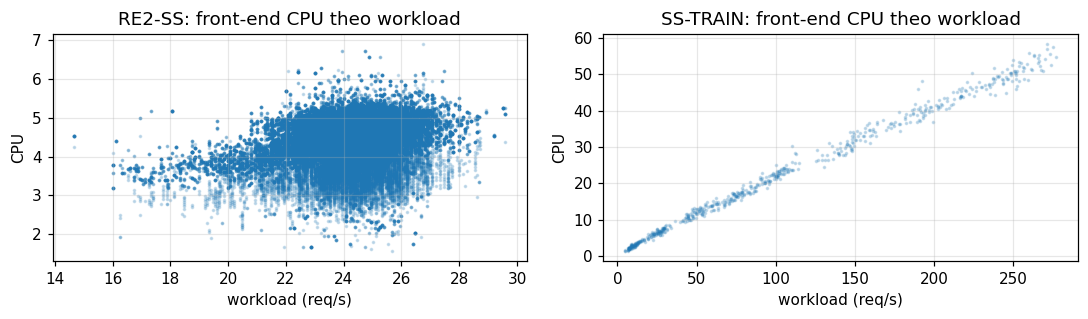

In [5]:
import feasibility_predictor as FP
from sklearn.linear_model import LinearRegression
ss_train = FP.load_runs(str(RAW / 'SS-TRAIN'))
rows = []
for s in ['front-end', 'catalogue', 'user', 'carts', 'orders']:
    for name, d in (('RE2-SS', df_re2), ('SS-TRAIN', ss_train)):
        x = d[[f'{s}_workload']].dropna(); y = d.loc[x.index, f'{s}_cpu']
        ok = y.notna(); x, y = x[ok], y[ok]
        r2 = LinearRegression().fit(x, y).score(x, y)
        rows.append({'service': s, 'bo': name, 'workload TB': x.iloc[:, 0].mean(), 'workload CV': x.iloc[:, 0].std() / x.iloc[:, 0].mean(),
                     'R2 CPU~workload': r2})
sig = pd.DataFrame(rows).pivot(index='service', columns='bo', values=['workload CV', 'R2 CPU~workload'])
display(sig.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, (name, d) in zip(axes, (('RE2-SS', df_re2), ('SS-TRAIN', ss_train))):
    ax.scatter(d['front-end_workload'], d['front-end_cpu'], s=2, alpha=.2)
    ax.set_title(f'{name}: front-end CPU theo workload'); ax.set_xlabel('workload (req/s)'); ax.set_ylabel('CPU')
plt.tight_layout(); plt.show()

**Hệ quả:** mọi con số "độ chính xác" của nhánh A trên RE2-SS phải đọc cùng cổng tín hiệu này. Đó là lý do nhánh B
phải tự dựng testbed có tải biến thiên thật.

## A2. Xây đồ thị

### A2.1 Bảng mẫu cạnh (`scm_graph_builder.DEFAULT_EDGE_TEMPLATES`)

Ý tưởng lấy từ CausIL: chất lượng đồ thị nhân quả được quyết định bởi **ràng buộc không gian tìm kiếm** bằng tri thức
miền, không phải thuật toán tìm kiếm. Chỉ cạnh thuộc một mẫu được khai báo mới **được phép** tồn tại; mọi cạnh khác
bị cấm.

- `intra` = trong cùng một service; `inter` = giữa hai service có quan hệ gọi.
- `forward` = cha là bên gọi; `reverse` = cha là bên bị gọi (độ trễ callee cộng vào caller).
- `learned=False` → cạnh **cấu trúc**, thêm thẳng. `learned=True` → phải **qua kiểm định** (A3).

In [6]:
import scm_graph_builder as GB, scm_edge_selector as ES
GRAPH = str(ROOT / 'src/graph/sockshop_agent_graph.json')
display(pd.DataFrame([{'ten': t.name, 'cha': t.parent_metric, 'con': t.child_metric, 'pham vi': t.scope,
                       'chieu': t.direction, 'phai hoc?': t.learned} for t in GB.DEFAULT_EDGE_TEMPLATES]))

,ten,cha,con,pham vi,chieu,phai hoc?
0,tier1_workload_propagation,workload,workload,inter,forward,False
1,tier2_cpu,workload,cpu,intra,None,False
2,tier2_mem,workload,mem,intra,None,False
3,tier2_latency,workload,latency-50,intra,None,False
4,cpu_backpressure,cpu,cpu,inter,forward,True
5,latency_backprop_causil,latency-50,latency-50,inter,reverse,True


### A2.2 Cạnh cấu trúc (Tier 1 + Tier 2)

- **Tier 1** — `workload(caller) → workload(callee)` theo mọi cạnh gọi trong đồ thị phụ thuộc: tải lan theo chiều gọi.
- **Tier 2** — trong mỗi service, `workload → cpu`, `workload → mem`, `workload → latency-50`.

Chỉ tạo cạnh khi **cả hai cột có trong dữ liệu** (vd. service DB không có cột workload nên bị bỏ).

In [7]:
struct = GB.structural_edges(GRAPH, DP.SERVICES, df_re2.columns, GB.DEFAULT_EDGE_TEMPLATES)
kind = lambda e: 'Tier1 workload->workload' if e[0].endswith('_workload') and e[1].endswith('_workload') else 'Tier2 ' + e[1].split('_', 1)[1]
print(f'{len(struct)} canh cau truc:')
display(pd.Series([kind(e) for e in struct]).value_counts().to_frame('so canh'))
print([e for e in struct if kind(e).startswith('Tier1')])

29 canh cau truc:


,so canh
Tier1 workload->workload,8
Tier2 cpu,7
Tier2 mem,7
Tier2 latency-50,7


[('front-end_workload', 'catalogue_workload'), ('front-end_workload', 'carts_workload'), ('front-end_workload', 'user_workload'), ('front-end_workload', 'orders_workload'), ('orders_workload', 'carts_workload'), ('orders_workload', 'user_workload'), ('orders_workload', 'payment_workload'), ('orders_workload', 'shipping_workload')]


## A3. Học cạnh — quy trình 4 pha cho mỗi mẫu `learned=True`

Hai loại cạnh phải học: **CPU backpressure** (`cpu(caller) → cpu(callee)`) và **lan truyền độ trễ kiểu CausIL**
(`latency(callee) → latency(caller)`).

1. **Ứng viên:** mọi cặp gọi trong đồ thị phụ thuộc có đủ cột.
2. **Chấm điểm HELD-OUT:** sắp dữ liệu theo workload của service con, **train 67% tải thấp, test 33% tải cao**. So
   mô hình con `~ workload` (cơ sở) với `~ workload + cha ứng viên` (mở rộng). Điểm = mức tăng R² **trên tập tải
   cao chưa thấy**. *Vì sao không in-sample:* R²/BIC in-sample từng chọn cạnh làm MAPE held-out tăng 298% → 499%.
   Cạnh có hệ số mới bằng 0 bị loại (hệ số 0 vẫn có thể cho MAPE đẹp).
3. **Knee-point:** sắp mức tăng giảm dần, cắt ở điểm khuỷu tay thay vì một ngưỡng cố định.
4. **An toàn OOD:** can thiệp `do(gateway_workload = base·(1+δ))` với δ ∈ {5…300}% **có và không có** cạnh; loại
   cạnh nào làm **đảo dấu** (tải tăng mà CPU dự đoán giảm) ở service chưa từng đảo dấu.


=== cpu_backpressure: 8 ung vien -> 3 qua held-out + knee-point


,parent_col,child_col,r2_base_heldout,r2_ext_heldout,r2_gain_heldout,mape_base_heldout,mape_ext_heldout
0,orders_cpu,shipping_cpu,-0.0025,0.2004,0.2029,68.30,65.17
1,orders_cpu,carts_cpu,-0.0019,0.1061,0.1080,55.02,52.91
2,front-end_cpu,user_cpu,-0.0318,-0.0074,0.0244,16.52,16.29
3,front-end_cpu,orders_cpu,0.0001,0.0177,0.0176,62.87,66.40
4,orders_cpu,user_cpu,-0.0318,-0.0195,0.0123,16.52,16.45
5,front-end_cpu,carts_cpu,-0.0019,0.0041,0.0060,55.02,53.37
6,front-end_cpu,catalogue_cpu,-0.0006,-0.0006,0.0000,49.93,49.93
7,orders_cpu,payment_cpu,-0.0002,-0.0002,-0.0000,13.07,13.46



=== latency_backprop_causil: 8 ung vien -> 2 qua held-out + knee-point


,parent_col,child_col,r2_base_heldout,r2_ext_heldout,r2_gain_heldout,mape_base_heldout,mape_ext_heldout
0,carts_latency-50,orders_latency-50,-0.0708,0.8990,0.9698,298.63,76.52
1,carts_latency-50,front-end_latency-50,-0.4568,0.0075,0.4644,10.64,7.80
2,orders_latency-50,front-end_latency-50,-0.4568,-0.0425,0.4144,10.64,8.07
3,user_latency-50,front-end_latency-50,-0.4568,-0.3451,0.1118,10.64,10.24
4,payment_latency-50,orders_latency-50,-0.0708,-0.0911,-0.0203,298.63,495.80


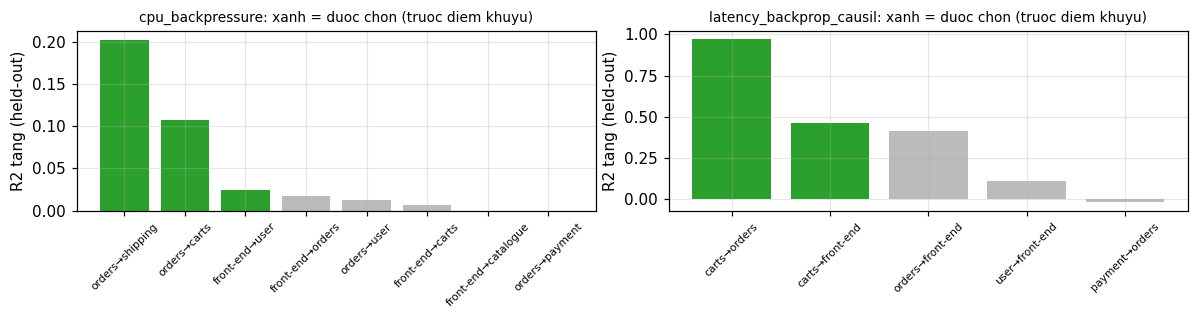

In [8]:
edge_reports = {}
for tpl in [t for t in GB.DEFAULT_EDGE_TEMPLATES if t.learned]:
    rep = GB.select_edges_for_template(tpl, GRAPH, df_re2, DP.SERVICES)      # pha 1-3 (chua OOD)
    edge_reports[tpl.name] = rep
    print(f"\n=== {tpl.name}: {len(rep['candidate_edges'])} ung vien -> {len(rep['selected_edges'])} qua held-out + knee-point")
    display(rep['scores'][['parent_col', 'child_col', 'r2_base_heldout', 'r2_ext_heldout', 'r2_gain_heldout',
                           'mape_base_heldout', 'mape_ext_heldout']])

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for ax, (name, rep) in zip(axes, edge_reports.items()):
    sc = rep['scores']; sel = set(rep['selected_edges'])
    ax.bar(range(len(sc)), sc['r2_gain_heldout'],
           color=['#2ca02c' if (p, c) in sel else '#bbb' for p, c in zip(sc.parent_col, sc.child_col)])
    ax.set_xticks(range(len(sc)), [f'{p.split("_")[0]}→{c.split("_")[0]}' for p, c in zip(sc.parent_col, sc.child_col)],
                  rotation=45, fontsize=7)
    ax.set_title(f'{name}: xanh = duoc chon (truoc diem khuyu)', fontsize=9); ax.set_ylabel('R2 tang (held-out)')
plt.tight_layout(); plt.show()

### A3.1 Pha 4 — kiểm an toàn OOD (cần fit DAG hai lần mỗi mẫu cạnh)

`CapacityAgent._build_extended_dag_fn()` dựng một DAG = cạnh cấu trúc + cạnh ứng viên, gán **đúng** quy tắc cơ chế
như DAG sản phẩm, rồi fit. Ô dưới chạy pha 4 cho cạnh CPU backpressure (~10 giây).

In [9]:
from capacity_agent import CapacityAgent
with quiet():
    ag = CapacityAgent()                       # huan luyen day du (A4) -- can de dung build_model_fn
build_fn = ag._build_extended_dag_fn(nx.DiGraph(struct), df_re2)
sel_cpu = edge_reports['cpu_backpressure']['selected_edges']
with quiet():
    ood = ES.validate_ood_safety(build_fn, df_re2, sel_cpu, DP.SERVICES, metric='cpu', injection_services=[ag.default_injection])
pv = ood.pivot_table(index=['service'], columns=['variant', 'delta_pct'], values='cpu_change_pct')
display(pv.round(1))
inv = ood[ood.sign_inverted].groupby('variant').size()
print('so o DAO DAU (tai tang ma CPU du doan giam):', inv.to_dict())
print('canh CPU cuoi cung trong DAG san pham:', [e for e in ag._last_edge_build['learned_edges'] if e[0].endswith('_cpu')])

variant   BASELINE_no_candidate_edges                                   WITH_candidate_edges                                  
delta_pct                         5     20     50     100    150    300                  5     20     50     100    150    300
service                                                                                                                       
carts                             6.5  12.3   23.9   43.2   62.6  120.5                 10.2  15.9   27.4   46.5   65.7  123.1
catalogue                        44.0  62.8  100.6  163.5  226.4  415.2                 44.0  62.8  100.6  163.5  226.4  415.2
front-end                         1.9   9.9   25.8   52.4   79.0  158.8                  1.9   9.9   25.8   52.4   79.0  158.8
orders                           14.9  22.0   36.2   59.8   83.5  154.4                 14.9  22.0   36.2   59.8   83.5  154.4
payment                          -6.0  -5.8   -5.4   -4.7   -3.9   -1.8                 -5.8  -5.6   -5.1   -4.4   -3.7   -1.5
shipping                          5.0   5.4    6.4    8.1    9.7   14.7                  0.3   3.0    8.6   17.9   27.2   55.1
user                              0.2   3.0    8.7   18.2   27.6   56.0                 -0.6   3.7   12.2   22.9   30.9   53.5

so o DAO DAU (tai tang ma CPU du doan giam): {'BASELINE_no_candidate_edges': 6, 'WITH_candidate_edges': 6}
canh CPU cuoi cung trong DAG san pham: [('orders_cpu', 'shipping_cpu'), ('orders_cpu', 'carts_cpu'), ('front-end_cpu', 'user_cpu')]


Số ô đảo dấu **bằng nhau** có và không có cạnh → cạnh mới không gây thêm đảo dấu nào → cả 3 cạnh được giữ. Các ô
đảo dấu sẵn có đến từ cơ chế nền (service có hiệu ứng gần 0 và nhiễu), không từ cạnh ứng viên.

Kết quả chọn cạnh được **cache** trong `data/processed/scm_cache/` (khoá = hash của đồ thị + dữ liệu + bảng mẫu), vì
pha 4 là phần đắt nhất; lần fit cuối cùng luôn chạy lại nên mô hình luôn tươi.

## A4. Gán cơ chế và huấn luyện DAG

`train_accurate_path()` ghép toàn bộ cạnh, **phá chu trình** nếu có (bỏ cạnh cuối của chu trình), lấy mẫu tối đa
2000 dòng, rồi gán cơ chế cho từng node (`_assign_dag_mechanisms`):

| Node | Cơ chế | Lý do |
|---|---|---|
| gốc (`front-end_workload`) | phân phối thực nghiệm | không có cha |
| `*_workload` có cha, `*_cpu`, `*_mem` | `LinearRegression(positive=True)` + nhiễu cộng | hệ số **không âm** → đơn điệu → Mệnh đề 2 dùng được |
| `*_latency-50` | `QueueingLatencyRegressor` + nhiễu cộng | M/M/1: độ trễ bùng nổ khi W → C |

**Hồi quy hàng đợi:** ước lượng trần `C = 1,5 × P99(W)` từ dữ liệu, biến đổi `W/(C − W)`, rồi hồi quy tuyến tính
**không âm** trên `[W, W/(C−W)]`. Hệ số âm trước đây làm 7/7 cơ chế độ trễ vi phạm tính đơn điệu; ép không âm vừa
sửa đơn điệu vừa **giảm** MAPE held-out.

In [10]:
g_dag = ag.dag_graph
print(f'DAG san pham: {g_dag.number_of_nodes()} node, {g_dag.number_of_edges()} canh '
      f'(cau truc {len(ag._last_edge_build["structural_edges"])} + hoc {len(ag._last_edge_build["learned_edges"])})')
from queueing_regressor import QueueingLatencyRegressor
rows = []
for n in nx.topological_sort(g_dag):
    parents = sorted(g_dag.predecessors(n))
    if not parents:
        rows.append({'node': n, 'cha': '(goc)', 'co che': 'thuc nghiem', 'he so': '', 'chan (intercept)': ''}); continue
    sk = ag.global_dag_model.causal_mechanism(n).prediction_model.sklearn_model
    m = sk.model_ if isinstance(sk, QueueingLatencyRegressor) else sk
    rows.append({'node': n, 'cha': ', '.join(parents), 'co che': type(sk).__name__,
                 'he so': np.round(m.coef_, 4).tolist(), 'chan (intercept)': round(float(m.intercept_), 4)})
display(pd.DataFrame(rows))

DAG san pham: 28 node, 34 canh (cau truc 29 + hoc 5)


,node,cha,co che,he so,chan (intercept)
0,front-end_workload,(goc),thuc nghiem,,
1,catalogue_workload,front-end_workload,LinearRegression,[0.1897],-0.5674
2,orders_workload,front-end_workload,LinearRegression,[0.03],1.2864
3,front-end_cpu,front-end_workload,LinearRegression,[0.0975],2.0555
4,front-end_mem,front-end_workload,LinearRegression,[0.0],104688027.648
5,catalogue_cpu,catalogue_workload,LinearRegression,[0.0639],-0.0066
6,catalogue_mem,catalogue_workload,LinearRegression,[0.0],6166286.336
7,catalogue_latency-50,catalogue_workload,QueueingLatencyRegressor,"[0.0, 0.0]",0.003
8,carts_workload,"front-end_workload, orders_workload",LinearRegression,"[0.3484, 0.2776]",-0.9099
9,user_workload,"front-end_workload, orders_workload",LinearRegression,"[0.3859, 4.2436]",0.2601


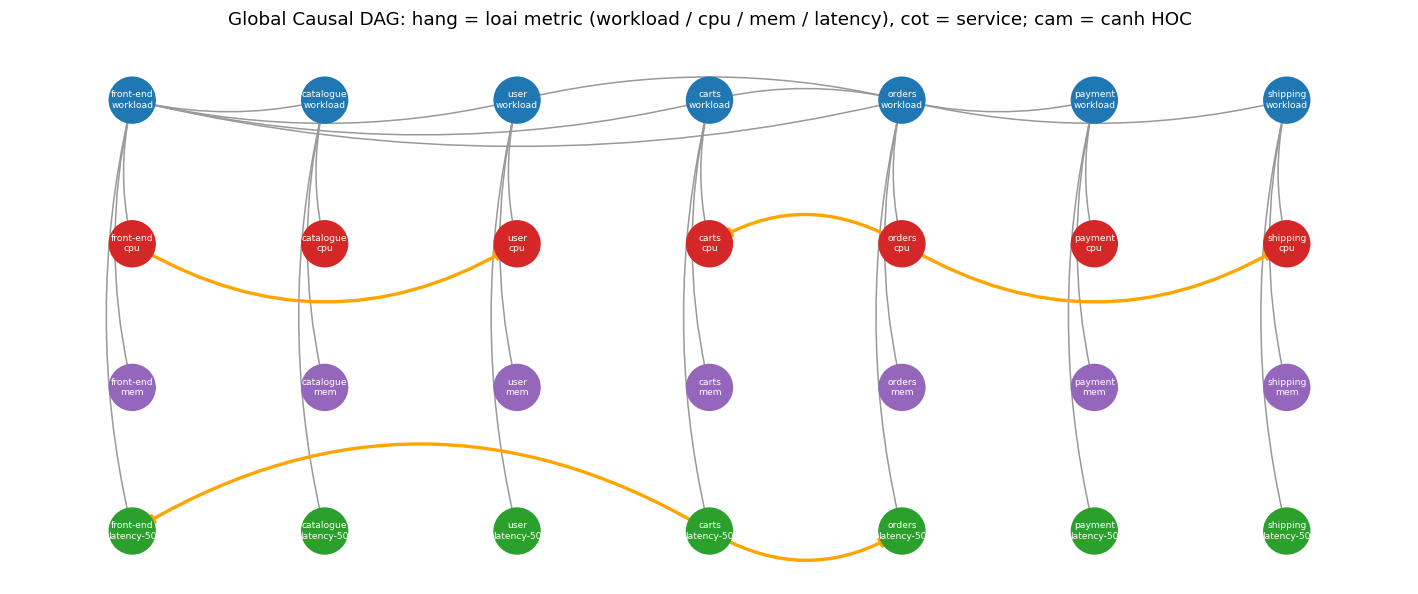

In [11]:
layer = {'workload': 0, 'cpu': 1, 'mem': 2, 'latency-50': 3}
svc_x = {s: i for i, s in enumerate(DP.SERVICES)}
pos = {n: (svc_x[n.split('_')[0]], -layer[n.split('_', 1)[1]]) for n in g_dag}
learned = set(map(tuple, ag._last_edge_build['learned_edges']))
fig, ax = plt.subplots(figsize=(13, 5.5))
nx.draw_networkx_nodes(g_dag, pos, ax=ax, node_size=900, node_color=[['#1f77b4', '#d62728', '#9467bd', '#2ca02c'][layer[n.split('_', 1)[1]]] for n in g_dag])
nx.draw_networkx_labels(g_dag, pos, {n: n.replace('_', '\n') for n in g_dag}, font_size=6, font_color='white', ax=ax)
nx.draw_networkx_edges(g_dag, pos, edgelist=[e for e in g_dag.edges if e not in learned], ax=ax, edge_color='#999', arrowsize=8,
                       connectionstyle='arc3,rad=0.12')
nx.draw_networkx_edges(g_dag, pos, edgelist=[e for e in g_dag.edges if e in learned], ax=ax, edge_color='orange', width=2.2,
                       arrowsize=12, connectionstyle='arc3,rad=0.3')
ax.set_title('Global Causal DAG: hang = loai metric (workload / cpu / mem / latency), cot = service; cam = canh HOC'); ax.axis('off')
plt.tight_layout(); plt.show()

Quan sát quan trọng từ hình: **không có cạnh nào từ CPU/mem sang độ trễ**. Cạnh backpressure là CPU → CPU và dừng
ở CPU, nên mô hình chưa diễn tả được "CPU bão hoà làm tăng độ trễ" — đúng cơ chế mà nhánh B thấy làm vỡ SLO.

## A5. Đường nhanh — 21 mô hình hai biến và giao thức OOD 67/33

`train_fast_path()` fit riêng `Workload → Target` cho mỗi (service × {CPU, Mem, Socket}). Giao thức đánh giá dùng
chung toàn dự án: **sắp theo workload, train 67% tải thấp, test 33% tải cao** — vì câu hỏi thật luôn là ngoại suy
lên tải cao hơn.

In [12]:
display(ag.accuracy_df[['service', 'metric', 'mape_pct', 'r2', 'tag', 'n_train', 'n_test']])

,service,metric,mape_pct,r2,tag,n_train,n_test
0,front-end,CPU,3.32,-2.194,EXCELLENT,1340,660
1,catalogue,CPU,100.75,-7.609,POOR,1340,660
2,user,CPU,5.33,-2.370,EXCELLENT,1340,660
3,carts,CPU,25.95,-3.978,POOR,1340,660
4,orders,CPU,15.41,-0.328,FAIR,1340,660
5,payment,CPU,2.27,-0.428,EXCELLENT,1340,660
6,shipping,CPU,8.62,-0.178,EXCELLENT,1340,660
7,front-end,Memory,2.16,-14.194,EXCELLENT,1340,660
8,catalogue,Memory,0.92,-1.259,EXCELLENT,1340,660
9,user,Memory,1.50,-0.571,EXCELLENT,1340,660


Chú ý R² **âm** ở nhiều dòng dù MAPE thấp: trên tập test tải cao, mô hình còn kém hơn dự đoán bằng trung bình —
MAPE thấp chỉ vì CPU gần như không đổi (xem cổng tín hiệu A1.1). Đây là ví dụ cụ thể của "đánh giá rỗng".

## A6. Suy luận can thiệp

Can thiệp luôn ở **gateway** — node gốc, không có cha. Với node gốc, `do(X = x)` trùng với điều kiện hoá `X = x`
(không có cạnh nào để cắt), nên toán tử `do()` không cho lợi thế gì so với hồi quy thường; giá trị nằm ở **đồ thị**
(tải đổ vào node nào). Vì vậy dự án dùng **forward tất định**: đi theo thứ tự tô-pô, gọi `.predict()` của từng cơ chế
trên giá trị điểm của cha, không lấy mẫu nhiễu.

In [13]:
from dowhy import gcm
from deterministic_forward import deterministic_forward
inj = f'{ag.default_injection}_workload'
base = float(ag.df_baseline[inj].mean()); target = base * 1.2
det, breached = deterministic_forward(g_dag, ag.global_dag_model, ag.df_baseline, {inj: target})
det0, _ = deterministic_forward(g_dag, ag.global_dag_model, ag.df_baseline, {inj: base})     # chinh mo hinh o delta = 0
np.random.seed(0)
with quiet():
    mc = gcm.interventional_samples(ag.global_dag_model, interventions={inj: lambda x: target}, num_samples_to_draw=2000)
cmp_ = pd.DataFrame({'du lieu (TB)': ag.df_baseline.mean(), 'mo hinh o delta=0': pd.Series(det0),
                     'forward tat dinh': pd.Series(det), 'Monte Carlo (TB 2000 mau)': mc.mean()})
cmp_['% doi so voi du lieu'] = 100 * (cmp_['forward tat dinh'] / cmp_['du lieu (TB)'] - 1)
cmp_['% doi so voi mo hinh'] = 100 * (cmp_['forward tat dinh'] / cmp_['mo hinh o delta=0'] - 1)
cmp_['lech tat dinh vs MC %'] = 100 * (cmp_['forward tat dinh'] / cmp_['Monte Carlo (TB 2000 mau)'] - 1)
print(f'do({inj}: {base:.2f} -> {target:.2f}, +20%)   node vuot tran hang doi: {breached}')
display(cmp_.drop(index=inj).round(3).sort_values('% doi so voi mo hinh', ascending=False))
print('so node co % doi AM khi tai TANG -- so voi du lieu:', int((cmp_['% doi so voi du lieu'] < -0.5).sum()),
      '| so voi mo hinh:', int((cmp_['% doi so voi mo hinh'] < -0.5).sum()))

do(front-end_workload: 24.17 -> 29.00, +20%)   node vuot tran hang doi: []


,du lieu (TB),mo hinh o delta=0,forward tat dinh,Monte Carlo (TB 2000 mau),% doi so voi du lieu,% doi so voi mo hinh,lech tat dinh vs MC %
catalogue_cpu,2.330000e-01,2.500000e-01,3.090000e-01,3.740000e-01,32.596,23.426,-17.332
catalogue_workload,4.027000e+00,4.017000e+00,4.934000e+00,4.924000e+00,22.529,22.825,0.215
carts_workload,8.056000e+00,8.068000e+00,9.792000e+00,9.795000e+00,21.557,21.370,-0.030
user_workload,1.813100e+01,1.812500e+01,2.060600e+01,2.063900e+01,13.650,13.689,-0.163
front-end_cpu,4.431000e+00,4.412000e+00,4.884000e+00,4.858000e+00,10.210,10.683,0.526
orders_cpu,2.031000e+00,2.054000e+00,2.246000e+00,2.276000e+00,10.544,9.356,-1.326
carts_cpu,2.144000e+00,2.181000e+00,2.345000e+00,2.378000e+00,9.381,7.526,-1.382
orders_workload,2.020000e+00,2.012000e+00,2.157000e+00,2.155000e+00,6.770,7.212,0.120
shipping_workload,2.012000e+00,2.010000e+00,2.127000e+00,2.122000e+00,5.723,5.847,0.241
user_cpu,9.190000e-01,9.170000e-01,9.690000e-01,9.700000e-01,5.438,5.749,-0.068


so node co % doi AM khi tai TANG -- so voi du lieu: 3 | so voi mo hinh: 0


In [14]:
with quiet():
    sim = ag.simulate_intervention(ag.default_injection, 20)
display(pd.DataFrame(sim).T[['n_hops', 'cpu_change_pct', 'cpu_confidence', 'mem_change_pct', 'latency_change_pct', 'latency_confidence']])

,n_hops,cpu_change_pct,cpu_confidence,mem_change_pct,latency_change_pct,latency_confidence
front-end,0,10.2,stable,0.4,-0.0,stable
catalogue,1,32.6,unstable,-0.7,0.2,stable
user,1,5.4,stable,-0.0,1.8,stable
carts,1,9.4,unstable,-0.0,5.8,unstable
orders,1,10.5,unstable,-0.1,4.8,stable
payment,2,-5.7,stable,-0.2,0.5,unstable
shipping,2,3.6,unstable,0.1,-4.8,stable


**Đọc hai bảng trên:**

- Forward tất định khớp Monte Carlo trong vài phần trăm ở node tuyến tính; lệch lớn hơn ở node độ trễ (hàm lồi —
  trung bình của hàm ≠ hàm của trung bình). Dự án chọn forward tất định vì không có nhiễu lấy mẫu và nhanh ~14×.
- ⚠️ `simulate_intervention()` tính `% đổi` **so với trung bình dữ liệu**, không so với chính mô hình ở δ = 0. Mô hình
  fit trên mẫu 2000 dòng nên giá trị dự đoán ở δ = 0 đã lệch trung bình dữ liệu; kết quả là vài node (vd.
  `payment_cpu`, `shipping_latency-50`) **báo giảm khi tải tăng**. So với mô hình ở δ = 0 thì không node nào giảm —
  đúng tính đơn điệu. Đây là lỗi cách báo cáo, không phải lỗi cơ chế (Phần C, A-8).
- `*_confidence` lấy từ độ ổn định của **chính cơ chế đó** (A8): `unstable` nghĩa là không nên tin con số ở cột đó.

## A7. Bao an toàn chứng nhận (Mệnh đề 2) và can thiệp đồng thời (Mệnh đề 3)

**Mệnh đề 2:** nếu **mọi** cơ chế đơn điệu không giảm theo từng cha (hệ số ≥ 0), thì với **mọi** δ ∈ [δ_min, δ_max],
giá trị điểm của mỗi node nằm giữa hai lần forward ở δ_min và δ_max. Hai lần forward là đủ — không cần quét.
Tiền điều kiện được **kiểm lại lúc chạy** (`_check_monotone_precondition`), không tin mù vào ràng buộc của solver;
vi phạm thì từ chối cấp chứng nhận.

In [15]:
print('vi pham tien dieu kien don dieu:', ag._check_monotone_precondition() or 'khong co')
env = ag.certified_envelope(ag.default_injection, 5, 50)
envdf = pd.DataFrame({k: v for k, v in env.items() if isinstance(v, dict)}).T
display(envdf.round(3))

# kiem chung bang cach quet: moi delta trong [5, 50] phai nam trong [lo, hi]
deltas = np.linspace(5, 50, 19); viol = 0
for dlt in deltas:
    vals, _ = deterministic_forward(g_dag, ag.global_dag_model, ag.df_baseline, {inj: base * (1 + dlt / 100)})
    viol += sum(not (envdf.loc[n, 'lo'] - 1e-9 <= vals[n] <= envdf.loc[n, 'hi'] + 1e-9) for n in envdf.index)
print(f'quet {len(deltas)} gia tri delta x {len(envdf)} node: {viol} lan nam NGOAI bao')

vi pham tien dieu kien don dieu: khong co


,lo,hi
catalogue_workload,4.246000e+00,6.309000e+00
carts_workload,8.499000e+00,1.237800e+01
user_workload,1.874500e+01,2.432700e+01
orders_workload,2.048000e+00,2.375000e+00
payment_workload,2.039000e+00,2.294000e+00
shipping_workload,2.039000e+00,2.303000e+00
front-end_cpu,4.530000e+00,5.591000e+00
catalogue_cpu,2.650000e-01,3.970000e-01
user_cpu,9.300000e-01,1.048000e+00
carts_cpu,2.222000e+00,2.591000e+00


quet 19 gia tri delta x 27 node: 0 lan nam NGOAI bao


**Mệnh đề 3 — nhiều yêu cầu cùng lúc:** bao đồng thời vẫn chỉ cần hai lần forward. Nhưng **không cộng dồn được**:
cơ chế độ trễ lồi (`W/(C−W)`), nên tác động thật của hai yêu cầu dồn vào cùng một nút thắt **lớn hơn** tổng hai tác
động riêng (bất đẳng thức Jensen). Ô dưới đo khoảng chênh "đồng thời − tổng ngây thơ" khi tăng tải cùng lúc ở gateway
và ở `orders`. (Bài đã **rút lại** khẳng định này trên dữ liệu thật Alibaba vì không đứng vững khi nhân đôi cửa sổ
quan sát; ở đây chỉ minh hoạ cơ chế.)

In [16]:
jn = ag.compare_joint_vs_naive_sum([ag.default_injection, 'orders'], delta_pct=50.0)
jdf = pd.DataFrame(jn).T
jdf['gap %'] = 100 * jdf['gap'] / jdf['naive_sum'].abs()
jdf['nam duoi orders?'] = [nx.has_path(g_dag, 'orders_workload', n) for n in jdf.index]
display(jdf.round(4).reindex(jdf['gap %'].abs().sort_values(ascending=False).index).head(10))
print('node co gap != 0:', sorted(jdf.index[jdf['gap'].abs() > 1e-9]))
qcoef = {n: ag.global_dag_model.causal_mechanism(n).prediction_model.sklearn_model.model_.coef_.round(4).tolist()
         for n in g_dag if n.endswith('latency-50') and g_dag.in_degree(n) > 0}
print('he so cua co che do tre [W..., W/(C-W)...]:', qcoef)

,joint,naive_sum,gap,gap %,nam duoi orders?
orders_cpu,3.4020,3.8823,-0.4803,-12.3716,True
shipping_workload,2.8345,3.1283,-0.2938,-9.3911,True
payment_workload,2.8070,3.0907,-0.2836,-9.1775,True
shipping_cpu,0.7821,0.8399,-0.0578,-6.8809,True
user_workload,27.1099,28.6494,-1.5395,-5.3736,True
carts_cpu,2.8084,2.9286,-0.1202,-4.1054,True
user_latency-50,0.0046,0.0046,0.0001,1.8313,True
user_cpu,1.0794,1.0966,-0.0172,-1.5667,True
carts_workload,12.5605,12.6612,-0.1007,-0.7954,True
payment_cpu,0.0881,0.0887,-0.0007,-0.7479,True


node co gap != 0: ['carts_cpu', 'carts_workload', 'orders_cpu', 'orders_mem', 'payment_cpu', 'payment_workload', 'shipping_cpu', 'shipping_latency-50', 'shipping_workload', 'user_cpu', 'user_latency-50', 'user_workload']
he so cua co che do tre [W..., W/(C-W)...]: {'front-end_latency-50': [0.0064, 0.0, 0.0, 0.0], 'catalogue_latency-50': [0.0, 0.0], 'user_latency-50': [0.0, 0.0002], 'carts_latency-50': [0.0, 0.0], 'orders_latency-50': [0.4209, 0.0, 0.0, 0.0], 'payment_latency-50': [0.0, 0.0], 'shipping_latency-50': [0.0, 0.0001]}


**Đọc kết quả — có hai hiệu ứng khác nhau, đừng lẫn:**

1. **Tính lồi (Mệnh đề 3) không xuất hiện:** trên RE2-SS, số hạng hàng đợi `W/(C−W)` của mọi cơ chế độ trễ được fit ra
   hệ số **0**, nên không có siêu cộng dồn — đúng lý do khẳng định này bị rút khỏi phần dữ liệu thật.
2. **Khoảng chênh khác 0 chỉ nằm ở hạ nguồn `orders`** và **âm** (dưới cộng dồn). Nguyên nhân là cấu trúc: Sock Shop chỉ
   có **một** gateway, nên can thiệp thứ hai (`orders`) luôn là con cháu của `front-end`. `do(orders_workload)` **cắt**
   cạnh `front-end → orders`; tổng ngây thơ vì thế đếm trùng phần tải đi qua đường đó. Mệnh đề 3 giả định các can
   thiệp nằm ở **các node gốc khác nhau** — trên hệ một gateway, kịch bản đó không tồn tại.

## A8. Độ ổn định, ảnh hưởng người dùng và biên dự phòng

- `evaluate_node_stability()`: đánh giá **chính cơ chế đang dùng** (không fit lại) trên 33% giá trị cao nhất của node.
  Tag POOR → node đó bị đánh dấu `unstable` trong mọi kết quả.
- `rank_user_impact()`: độ co giãn — % thay đổi của một node độ trễ khi một node khác tăng 1%, qua forward tất định.
- `compute_headroom()`: đổi dự đoán thành **% biên còn lại** tới mức cao nhất đã quan sát (P99 của node) — vì trần năng
  lực vật lý không định danh được từ dữ liệu chưa bão hoà.

In [17]:
with quiet():
    stab = ag.evaluate_node_stability(); imp = ag.rank_user_impact(); keys = ag.select_key_nodes()
display(stab)
print('Tag theo loai metric:'); display(pd.crosstab(stab.node.str.split('_', n=1).str[1], stab.tag))
print('\nTop anh huong nguoi dung (do co gian):'); display(imp.head(10))
print('\nselect_key_nodes:', {k: v for k, v in keys.items()})

,node,mape_pct,r2,n_train,n_test,tag
0,catalogue_workload,5.80,-1.417,42535,20951,EXCELLENT
1,carts_workload,7.60,-1.635,42535,20951,EXCELLENT
2,user_workload,5.13,-1.711,42535,20951,EXCELLENT
3,orders_workload,16.96,-0.840,42535,20951,FAIR
4,payment_workload,8.04,-0.319,42535,20951,EXCELLENT
5,shipping_workload,6.49,0.120,42535,20951,EXCELLENT
6,front-end_cpu,10.31,-6.047,42535,20951,FAIR
7,catalogue_cpu,34.00,-0.003,42535,20951,POOR
8,user_cpu,15.42,-6.525,42535,20951,FAIR
9,carts_cpu,30.31,-0.081,42535,20951,POOR


Tag theo loai metric:


tag,EXCELLENT,FAIR,POOR
node,,,
cpu,0,3,4
latency-50,1,4,2
mem,1,0,6
workload,5,1,0



Top anh huong nguoi dung (do co gian):


,node,target_node,elasticity,abs_elasticity,n_hops
0,carts_latency-50,orders_latency-50,0.487788,0.487788,1
1,user_workload,user_latency-50,0.137006,0.137006,1
2,front-end_workload,user_latency-50,0.086248,0.086248,2
3,orders_workload,user_latency-50,0.057954,0.057954,2
4,shipping_workload,shipping_latency-50,0.055580,0.055580,1
5,orders_workload,shipping_latency-50,0.044279,0.044279,2
6,carts_latency-50,front-end_latency-50,0.022751,0.022751,1
7,front-end_workload,shipping_latency-50,0.014096,0.014096,3
8,front-end_workload,catalogue_latency-50,0.008603,0.008603,2
9,catalogue_workload,catalogue_latency-50,0.007332,0.007332,1



select_key_nodes: {'high_impact': ['carts_latency-50', 'user_workload'], 'recommended': ['user_workload'], 'unstable_but_impactful': ['carts_latency-50']}


In [18]:
hr = ag.compute_headroom(sim)
display(pd.DataFrame({(s, m): v for s, d in hr.items() for m, v in d.items() if isinstance(v, dict)}).T
        [['baseline', 'projected', 'ceiling_p99', 'consumed_pct', 'remaining_pct', 'status']].round(3))

baseline     projected  ceiling_p99 consumed_pct remaining_pct            status
front-end cpu              4.43          4.88       5.4902         46.5          53.5         UNDECIDED
          mem               NaN           NaN          NaN          NaN           NaN  not_forecastable
          latency          0.03          0.03       0.0475          0.0         100.0                OK
catalogue cpu               NaN           NaN          NaN          NaN           NaN  not_forecastable
          mem               NaN           NaN          NaN          NaN           NaN  not_forecastable
          latency           0.0           0.0       0.0032          0.0         100.0                OK
user      cpu              0.92          0.97        1.251         14.5          85.5                OK
          mem               NaN           NaN          NaN          NaN           NaN  not_forecastable
          latency           0.0           0.0       0.0062          0.0         100.0                OK
carts     cpu               NaN           NaN          NaN          NaN           NaN  not_forecastable
          mem               NaN           NaN          NaN          NaN           NaN  not_forecastable
          latency           NaN           NaN          NaN          NaN           NaN  not_forecastable
orders    cpu               NaN           NaN          NaN          NaN           NaN  not_forecastable
          mem      331430305.76  331139731.05  639045632.0         -0.1         100.0                OK
          latency           0.1           0.1       1.2898          0.0         100.0                OK
payment   cpu              0.09          0.09       0.1112          0.0         100.0                OK
          mem               NaN           NaN          NaN          NaN           NaN  not_forecastable
          latency           NaN           NaN          NaN          NaN           NaN  not_forecastable
shipping  cpu               NaN           NaN          NaN          NaN           NaN  not_forecastable
          mem               NaN           NaN          NaN          NaN           NaN  not_forecastable
          latency           0.0           0.0       0.0073          0.0         100.0                OK

**Tóm tắt nhánh A:** đồ thị đứng vững dưới kiểm định can thiệp (cạnh cấu trúc + 5 cạnh học qua held-out và OOD),
chứng nhận đơn điệu được kiểm lúc chạy. Nhưng: (1) RE2-SS thiếu tín hiệu tải nên độ chính xác trên nó không chứng
minh gì; (2) nhiều cơ chế CPU/độ trễ bị gắn POOR; (3) chưa có cạnh CPU → độ trễ; (4) `do()` không cho lợi thế vì can
thiệp luôn ở gốc. Nhánh B được xây để trả lời câu hỏi khả thi trên dữ liệu **có** tín hiệu.

---
# PHẦN B — Bộ dự đoán khả thi cho tính năng chưa tồn tại

Phần này đi theo đúng thứ tự dữ liệu chảy qua bộ dự đoán, **kể cả quy trình huấn luyện và đóng băng**: bài toán →
dữ liệu → đồ thị → fit cơ chế → hiệu chỉnh u* → fit tham số P2 → probe `k` → đóng băng → dự đoán → tiến cứu → chẩn đoán.

## B1. Bài toán

Đội phát triển muốn thêm một **tính năng chưa hề tồn tại** (vd. *đăng nhập nhanh*) vào Sock Shop. Câu hỏi
**trước khi viết dòng code nào**: *với kiến trúc hiện có, hệ thống còn đạt SLO ở mức tải đỉnh L không, và
service nào nghẽn trước?*

- Vì tính năng chưa tồn tại nên **không có telemetry của chính nó**. Mô hình chỉ được học từ dữ liệu *không có
  tính năng* (baseline), rồi *can thiệp* thêm tải của tính năng vào. Đây là câu hỏi *what-if*, không phải dự báo
  chuỗi thời gian.
- **Phạm vi:** tính năng chỉ thêm traffic đi qua service và cạnh gọi **đã có**; không thêm service/cạnh mới.
- **Đáp án:** sau khi đóng băng dự đoán, cài tính năng thật rồi tăng tải từng bậc (*ramp*) tới khi vỡ SLO.
  Mức tải cuối còn đạt SLO gọi là **điểm gãy** `lo`, bậc đầu vi phạm là `hi`.

SLO và trần CPU được chốt trong file cấu hình, không cắm cứng trong code:

In [19]:
slo = FP.load_slo()
limits = json.load(open(ROOT / 'deploy/sockshop/limits.json', encoding='utf-8'))
cores = {k: v for k, v in limits['configs']['RE2'].items()}
print(f"SLO: p99 <= {slo['p99_s']*1000:.0f} ms, ti le loi <= {slo['err_rate']*100:.0f}%")
display(pd.Series(cores, name='tran CPU (core), cau hinh RE2').to_frame())

SLO: p99 <= 250 ms, ti le loi <= 1%


,"tran CPU (core), cau hinh RE2"
carts,0.5
carts-db,0.5
catalogue,0.5
front-end,0.5
orders,0.5
orders-db,0.5
payment,0.1
queue-master,0.5
shipping,0.5
user,0.2


Trần **RE2** chép lại giới hạn CPU của bộ dữ liệu RCAEval RE2-SS (0,5 core cho hầu hết service; `user` 0,2;
`payment` 0,1). Hai cấu hình thử khác (C1, C2) **thất bại** vì hạn ngạch nhỏ gây CFS throttling — SLO vỡ ở mức
sử dụng CPU rất thấp, ngoài phạm vi mô hình. Vì vậy mọi kết quả dưới đây chỉ ở RE2.

## B1.5 Các tính năng **thêm vào** để sinh dữ liệu — khai báo, hiện thực, và sàn phân giải

Dữ liệu không tự có: mỗi "tính năng mới" là **code thật thêm vào front-end của Sock Shop**, rồi
đo lại hệ thống. Ba thứ phải khớp nhau, và ô dưới kiểm cả ba:

| thành phần | ở đâu | vai trò |
|---|---|---|
| **sinh tải** | `FEATURES` trong `papers/p1_du_phong/experiments/collect/load_sweep_collect.py` | endpoint, `anchor` (% tải mang tính năng), `archetype` |
| **hiện thực** | `deploy/sockshop/front-end/features*/index.js` + `DESIGN.md` cạnh nó | code Express thật; DESIGN.md khai báo **chuỗi gọi backend có thứ tự** |
| **đo lại** | `data/processed/frozen/k_measured*.json` | `chain_measured` và `measured_per_use` **đo bằng probe** trên hệ thật |

Đây là chỗ bộ dự đoán lấy đầu vào: P0/P1/P2 chỉ biết **khai báo** (archetype + chuỗi taxonomy +
anchor); P3 dùng thêm `k` **đo được**. Nên câu hỏi quyết định là: khai báo có đủ phân giải để
phân biệt hai tính năng khác nhau hay không?

In [20]:
import re, glob
from collections import defaultdict

# --- 1. hien thuc: route nao o bo nao, co DESIGN.md khong ---
HIEN_THUC = {}
for p in sorted(glob.glob(str(ROOT / 'deploy/sockshop/front-end/features*/index.js'))):
    src = open(p, encoding='utf-8', errors='ignore').read()
    goi_bo = os.path.basename(os.path.dirname(p))
    co_design = os.path.exists(os.path.join(os.path.dirname(p), 'DESIGN.md'))
    for m in re.finditer(r'app\.(?:get|post)\("([^"]+)"', src):
        HIEN_THUC[m.group(1)] = (goi_bo, src[:m.start()].count('\n') + 1, co_design)

# --- 2. probe: chuoi va k do duoc (gop moi tep k_measured*) ---
KDO = {}
for f in sorted(glob.glob(str(FROZEN / 'k_measured*.json'))):
    for k, v in json.load(open(f, encoding='utf-8'))['features'].items():
        KDO.setdefault(k, {}).update(v)

# --- 3. nang luc DO DUOC cho tung tinh nang (he so x1, moi phien do) ---
NL = defaultdict(list)
for sp in list(RAW.glob('SS-*/ramp_*/run*/steps.json')) + list(RAW.glob('SS-*/*/ramp_*/run*/steps.json')):
    j = json.load(open(sp, encoding='utf-8')); f = j.get('feature', 'base'); lo = j['breakpoint']['lo']
    if f == 'base' or lo is None or f not in HARNESS.FEATURES:
        continue
    if round(j.get('feature_pct', 0) / HARNESS.FEATURES[f]['anchor'], 3) == 1.0:
        NL[f].append(lo)

hang = []
for k, v in HARNESS.FEATURES.items():
    ep = v['req'][1].split('?')[0]
    bo_, dong, design = HIEN_THUC.get(ep, ('?', 0, False))
    kk = KDO.get(k, {})
    tx, md_ = kk.get('chain_taxonomy') or [], kk.get('chain_measured') or []
    hang.append({'tinh nang': k, 'endpoint': ep, 'anchor %': v['anchor'], 'archetype': v['archetype'],
                 'bo hien thuc': bo_, 'dong': dong, 'DESIGN.md': 'co' if design else 'KHONG',
                 'chuoi taxonomy': '->'.join(tx), 'chuoi do duoc': '->'.join(md_),
                 'lech': '' if tx == md_ else ('thu tu' if set(tx) == set(md_) else 'TAP KHAC'),
                 'nang luc do (trung vi)': float(np.median(NL[k])) if NL[k] else None,
                 'n lan do': len(NL[k])})
TN = pd.DataFrame(hang).set_index('tinh nang')
display(TN[['endpoint', 'anchor %', 'bo hien thuc', 'dong', 'DESIGN.md', 'lech',
            'nang luc do (trung vi)', 'n lan do']])
print(f"{len(TN)} tinh nang | hien thuc day du: {(TN['bo hien thuc'] != '?').sum()}/{len(TN)}"
      f" | co probe: {(TN['chuoi do duoc'] != '').sum()}/{len(TN)}"
      f" | thieu DESIGN.md: {sorted(TN[TN['DESIGN.md'] == 'KHONG']['bo hien thuc'].unique())}")
print(f"chuoi khai bao KHAC chuoi do duoc: {(TN.lech == 'TAP KHAC').sum()} khac TAP dich vu, "
      f"{(TN.lech == 'thu tu').sum()} chi khac THU TU")

,endpoint,anchor %,bo hien thuc,dong,DESIGN.md,lech,nang luc do (trung vi),n lan do
tinh nang,,,,,,,,
promo,/promo,20,features,50,KHONG,,150.0,2
recs,/recommendations,30,features,104,KHONG,thu tu,120.0,2
track,/track,15,features,158,KHONG,,170.0,2
review,/reviews,10,features,191,KHONG,thu tu,180.0,2
cartsum,/cart/summary,10,features_indep,162,co,TAP KHAC,160.0,4
quickadd,/cart/quick,15,features_indep,229,co,,70.0,4
express,/checkout/express,25,features_indep,287,co,thu tu,60.0,3
browse,/catalogue/browse,10,features_prosp,62,co,,200.0,1
login,/login/quick,10,features_prosp2,101,co,TAP KHAC,155.0,8


18 tinh nang | hien thuc day du: 18/18 | co probe: 18/18 | thieu DESIGN.md: ['features']
chuoi khai bao KHAC chuoi do duoc: 7 khac TAP dich vu, 4 chi khac THU TU


In [21]:
# --- SAN PHAN GIAI: tinh nang nao co KHAI BAO GIONG HET nhau? ---
# P0/P1/P2 chi thay (archetype, chuoi taxonomy, anchor). Hai tinh nang trung ca ba thi
# MOI mo hinh chi dua tren khai bao deu BAT BUOC du doan giong nhau cho chung.
nhom = defaultdict(list)
for k in HARNESS.FEATURES:
    nhom[(HARNESS.FEATURES[k]['archetype'], TN.loc[k, 'chuoi taxonomy'],
          HARNESS.FEATURES[k]['anchor'])].append(k)

sp_hang, tran = [], []
for (arch, chuoi, anc), v in sorted(nhom.items(), key=lambda kv: -len(kv[1])):
    if len(v) < 2:
        continue
    nl = {f: TN.loc[f, 'nang luc do (trung vi)'] for f in v}
    co = [x for x in nl.values() if x]
    r = max(co) / min(co) if len(co) > 1 else None
    if r:
        tran.append(r)
    sp_hang.append({'archetype': arch, 'anchor %': anc, 'tinh nang': ', '.join(v),
                    'nang luc do duoc': ', '.join(f'{f}={nl[f]:.0f}' for f in v if nl[f]),
                    'trai': f'{r:.2f}x' if r else '-'})
display(pd.DataFrame(sp_hang).set_index('archetype'))
trong_nhom = sum(len(v) for v in nhom.values() if len(v) > 1)
print(f"{trong_nhom}/{len(HARNESS.FEATURES)} tinh nang nam trong mot nhom khai bao giong het nhau")
print(f"SAN PHAN GIAI cua mo hinh dua tren khai bao: nang luc that lech toi {max(tran):.2f} lan "
      f"ben trong mot nhom ma mo hinh BUOC phai du doan giong nhau")

# --- probe co cuu duoc khong? Huong cua k so voi huong cua nang luc ---
print('\nHai cap chat nhat -- probe co tach duoc khong, va tach dung chieu khong?')
for a, b in [('quickadd', 'wishlist'), ('express', 'reorder')]:
    ka, kb = KDO[a]['measured_per_use'], KDO[b]['measured_per_use']
    ta, tb = sum(ka.values()), sum(kb.values())
    na, nb_ = TN.loc[a, 'nang luc do (trung vi)'], TN.loc[b, 'nang luc do (trung vi)']
    khac = {s: (ka[s], kb.get(s, 0)) for s in ka if abs(ka[s] - kb.get(s, 0)) > 1e-9}
    print(f"  {a} vs {b}: tong k do duoc {ta:.2f} vs {tb:.2f} | nang luc {na:.0f} vs {nb_:.0f} req/s")
    print(f"      khac o: {khac}")
    print(f"      -> nhieu loi goi hon MA nang luc CAO hon: "
          f"{'DUNG -- moi mo hinh don dieu theo k se xep SAI thu tu' if (tb > ta) == (nb_ > na) else 'khong'}")

,anchor %,tinh nang,nang luc do duoc,trai
archetype,,,,
RECOMMEND_PRODUCTS,30,"recs, account, orderfull","recs=120, account=125, orderfull=125",1.04x
GET_CATALOGUE,10,"browse, catsearch, related","browse=200, catsearch=195, related=155",1.29x
TRACK_PACKAGE,15,"track, orderhist","track=170, orderhist=155",1.10x
VIEW_CART,10,"cartsum, preview","cartsum=160, preview=155",1.03x
ADD_TO_CART,15,"quickadd, wishlist","quickadd=70, wishlist=125",1.79x
PLACE_ORDER,25,"express, reorder","express=60, reorder=100",1.67x


14/18 tinh nang nam trong mot nhom khai bao giong het nhau
SAN PHAN GIAI cua mo hinh dua tren khai bao: nang luc that lech toi 1.79 lan ben trong mot nhom ma mo hinh BUOC phai du doan giong nhau

Hai cap chat nhat -- probe co tach duoc khong, va tach dung chieu khong?
  quickadd vs wishlist: tong k do duoc 4.00 vs 4.05 | nang luc 70 vs 125 req/s
      khac o: {'carts': (2.0, 2.05)}
      -> nhieu loi goi hon MA nang luc CAO hon: DUNG -- moi mo hinh don dieu theo k se xep SAI thu tu
  express vs reorder: tong k do duoc 14.00 vs 15.00 | nang luc 60 vs 100 req/s
      khac o: {'orders': (1.0, 2.0)}
      -> nhieu loi goi hon MA nang luc CAO hon: DUNG -- moi mo hinh don dieu theo k se xep SAI thu tu


### Đọc kết quả B1.5 — vì sao có một **sàn phân giải** không vượt được

Ba điều đo được, và điều thứ ba là lời giải cho `quickadd` (câu hỏi bỏ ngỏ lâu nay):

1. **Hiện thực đầy đủ 18/18**, nhưng bộ `features/` (promo, recs, track, review — chính bộ đã
   fit tham số `c_s`, `x` của P2) **thiếu `DESIGN.md`**, trong khi 5 bộ còn lại đều có. Chuỗi gọi
   của bốn tính năng nền tảng nhất vì vậy chỉ tồn tại trong code, không có bản khai báo đọc được.
2. **11/18 tính năng có chuỗi khai báo khác chuỗi đo được** — 7 khác hẳn *tập* dịch vụ, 4 chỉ
   khác thứ tự. Taxonomy viết tay không mô tả đúng việc hệ thống thật làm.
3. **14/18 tính năng nằm trong một nhóm khai báo giống hệt nhau.** `quickadd` và `wishlist` trùng
   cả archetype (`ADD_TO_CART`), cả chuỗi taxonomy (`front-end→catalogue→carts`), cả anchor (15%)
   — nên P0/P1/P2 **buộc** phải dự đoán giống nhau cho chúng. Năng lực đo được: **70 vs 125 req/s,
   lệch 1,79 lần.** Cặp `express`/`reorder` lệch 1,67 lần.

Và probe cũng không cứu được: `k` đo được có khác, nhưng **ngược chiều**. `wishlist` gọi `carts`
*nhiều hơn* (2,05 vs 2,00) mà năng lực *cao hơn*; `reorder` gọi `orders` *gấp đôi* mà năng lực
*cao hơn*. Trong cả hai cặp, **nhiều lời gọi hơn lại đi với năng lực cao hơn** — nên mọi mô hình
đơn điệu tăng theo số lời gọi, dù dùng khai báo (P2) hay dùng `k` đo được (P3), đều xếp **sai thứ
tự** hai cặp này.

**Kết luận cho bài báo:** sai số còn lại của mô hình không phải do tham số chưa tinh. Nó là *sàn*:
mô hình chỉ có **một loại tài nguyên (CPU) và một đại lượng đếm (số lời gọi)**, trong khi khác biệt
thật giữa `quickadd` và `wishlist` nằm ở **chi phí mỗi lời gọi** — I/O, khoá, kết nối — thứ không
có node nào trong đồ thị biểu diễn. Đây là hạn chế **cấu trúc**, và nó đặt trần cho mọi biến thể
P0–P3 cùng một lúc. Nó cũng là lý do thứ hai (cùng với độ trôi ở
[nb02 §6b](02_quy_trinh_he_thong_va_thuc_nghiem.ipynb)) để báo cáo **phán quyết an toàn** thay vì
con số req/s.

## B2. Dữ liệu

### B2.1 Các bộ dữ liệu và vai trò

| Thư mục `data/raw/` | Vai trò | Có tính năng? | Trần CPU |
|---|---|---|---|
| `SS-TRAIN` | **Huấn luyện** cơ chế ρ, α, β (quét tải 10→250 req/s) | Không | Không trần |
| `SS-LIMITS` (ramp `base`) | Hiệu chỉnh ngưỡng **u*** | Không | RE2 |
| `SS-LIMITS` (promo, recs) | Tập **phát triển** — fit tham số P2 (`c_s`, `x`) | Có | RE2 |
| `SS-LIMITS` (track, review) | Tập **khoá** — mở đúng một lần | Có | RE2 |
| `SS-LIMITS-CLEAN` | Tính năng do agent độc lập cài (hồi cứu) | Có | RE2 |
| **`SS-PROSP2`** | **Tiến cứu** n = 10, dự đoán đóng băng *trước* khi đo | Có | RE2 |
| `SS-VERIFY*`, `SS-PROSP2-R2/R3`, `SS-PROSP4*` | Kiểm hệ / nguồn đã gộp / chẩn đoán | — | RE2 |

Dữ liệu thô **không nằm trong git** (`.gitignore`), chỉ có trên máy đo.

In [22]:
rows = []
for d in sorted(RAW.glob('SS-*')):
    steps = list(d.glob('ramp_*/run*/steps.json'))
    feats = sorted({p.parent.parent.name.replace('ramp_', '') for p in steps})
    rows.append({'thu_muc': d.name, 'so_ramp': len(steps), 'o (tinh nang_cuong do)': ', '.join(feats)[:110]})
display(pd.DataFrame(rows))

,thu_muc,so_ramp,o (tinh nang_cuong do)
0,SS-CALIBRATION,0,
1,SS-LIMITS,21,"base, promo_x1, promo_x2, recs_x1, recs_x2, re..."
2,SS-LIMITS-C1,3,base
3,SS-LIMITS-C2,1,base
4,SS-LIMITS-CLEAN,13,"base, browse_x1, browse_x2, cartsum_x1, cartsu..."
5,SS-LIMITS-INDEP,16,"base, cartsum_x1, cartsum_x2, express_x1, expr..."
6,SS-LIMITS-PROSP,1,base
7,SS-LOADSWEEP,0,
8,SS-PROSP2,0,
9,SS-TRAIN,0,


### B2.2 Một ramp mẫu: `login`, lần lặp 1

Mỗi ramp ghi `steps.json`: với từng bậc tải `target_rps` có p99 toàn hệ, p99 **riêng request tính năng**
(`feat_p99`), tỉ lệ lỗi, và cờ vi phạm. Tải tính năng = `target_rps × anchor%` (anchor của `login` là 10%,
chính là Δ trong mô hình — xem Phần C, hạn chế M5).

,target_rps,feat_rps,ok_per_s,p50,p99,feat_p99,err_rate,violated
0,40,4.0,46.0,0.018,0.077,0.115,0.0,False
1,50,5.0,52.2,0.016,0.066,0.069,0.0,False
2,65,6.5,72.8,0.015,0.075,0.096,0.0,False
3,80,8.0,85.7,0.018,0.075,0.080,0.0,False
4,100,10.0,110.5,0.021,0.102,0.137,0.0,False
5,125,12.5,136.4,0.044,0.227,0.489,0.0,False
6,155,15.5,172.2,0.048,0.308,0.485,0.0,True
7,195,19.5,123.7,3.106,26.467,31.130,0.0,True


diem gay: {'lo': 125, 'hi': 155, 'why': ['p99'], 'transient': []}


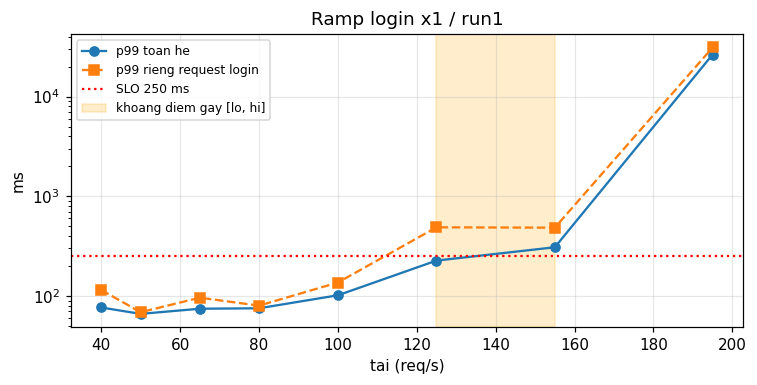

In [23]:
def read_steps(path):
    j = json.load(open(path, encoding='utf-8'))
    return j, pd.DataFrame(j['steps'])

j, st = read_steps(bo('SS-PROSP2') / 'ramp_login_x1/run1/steps.json')
display(st[['target_rps', 'feat_rps', 'ok_per_s', 'p50', 'p99', 'feat_p99', 'err_rate', 'violated']].round(3))
print('diem gay:', j['breakpoint'])

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(st.target_rps, st.p99 * 1000, 'o-', label='p99 toan he')
ax.plot(st.target_rps, st.feat_p99 * 1000, 's--', label='p99 rieng request login')
ax.axhline(slo['p99_s'] * 1000, color='red', ls=':', label='SLO 250 ms')
ax.axvspan(j['breakpoint']['lo'], j['breakpoint']['hi'], color='orange', alpha=.2, label='khoang diem gay [lo, hi]')
ax.set_yscale('log'); ax.set_xlabel('tai (req/s)'); ax.set_ylabel('ms'); ax.legend(fontsize=8)
ax.set_title('Ramp login x1 / run1'); plt.tight_layout(); plt.show()

**Đọc biểu đồ:** độ trễ gần như phẳng rồi **tăng vọt** khi một node hết CPU — đó là lý do dùng ngưỡng mức sử
dụng CPU (`u*`) để dự đoán điểm gãy. Chú ý đường `login` đã vượt SLO *trước* toàn hệ: tuyến của chính tính năng
vỡ trước (mục B7).

### B2.3 Telemetry từng giây — `simple_metrics.csv`

Mỗi dòng là một giây. Với mỗi service `s` có `s_cpu` (đơn vị: % của 1 core, nên **trần C_s = 100 × cores**),
`s_workload` (request/giây tới service), các phân vị độ trễ. Cột `gt_*` là **nhãn thí nghiệm** (bậc tải,
tính năng, cờ khởi động `gt_step_warm`) — tách tiền tố để không bao giờ lẫn vào đặc trưng.

he thong                 ['time', 'vm_cpu_util', 'vm_mem_avail_mb']
carts                    ['carts_cpu', 'carts_mem', 'carts_socket', 'carts_diskio', 'carts_workload', 'carts_latency-50', 'carts_latency-90', 'carts_latency-95', 'carts_latency-99', 'carts_latency-mean', 'carts_error']
carts-db                 ['carts-db_cpu', 'carts-db_mem', 'carts-db_socket', 'carts-db_diskio']
catalogue                ['catalogue_cpu', 'catalogue_mem', 'catalogue_socket', 'catalogue_diskio', 'catalogue_workload', 'catalogue_latency-50', 'catalogue_latency-90', 'catalogue_latency-95', 'catalogue_latency-99', 'catalogue_latency-mean', 'catalogue_error']
catalogue-db             ['catalogue-db_cpu', 'catalogue-db_mem', 'catalogue-db_socket', 'catalogue-db_diskio']
edge-router              ['edge-router_cpu', 'edge-router_mem', 'edge-router_socket', 'edge-router_diskio']
front-end                ['front-end_cpu', 'front-end_mem', 'front-end_socket', 'front-end_diskio', 'front-end_workload', 'front-end_l

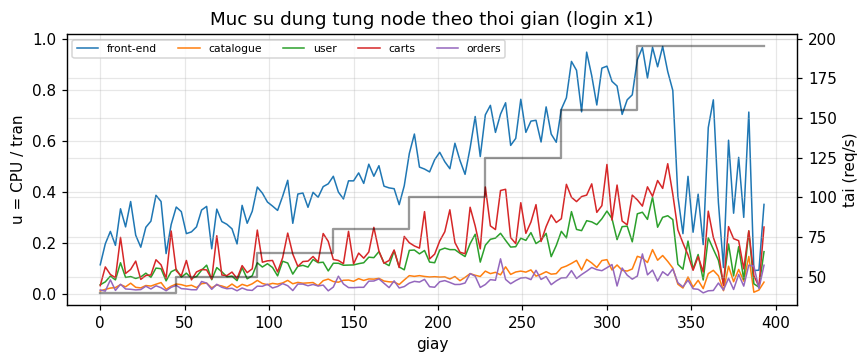

In [24]:
sm = pd.read_csv(bo('SS-PROSP2') / 'ramp_login_x1/run1/simple_metrics.csv')
groups = {}
for c in sm.columns:
    key = 'nhan thi nghiem (gt_*)' if c.startswith('gt_') else ('he thong' if c in ('time', 'vm_cpu_util', 'vm_mem_avail_mb') else c.split('_')[0])
    groups.setdefault(key, []).append(c)
for k, v in groups.items():
    print(f'{k:24s} {v}')

SVC = FP.SCORED
cap = {s: 100 * cores[s] for s in SVC}
fig, ax = plt.subplots(figsize=(8, 3.4))
for s in SVC:
    ax.plot(sm['time'] - sm['time'].iloc[0], sm[f'{s}_cpu'] / cap[s], lw=1, label=s)
ax2 = ax.twinx(); ax2.step(sm['time'] - sm['time'].iloc[0], sm['gt_target_rps'], color='k', alpha=.4, where='post')
ax.set_xlabel('giay'); ax.set_ylabel('u = CPU / tran'); ax2.set_ylabel('tai (req/s)')
ax.legend(fontsize=7, ncol=5, loc='upper left'); ax.set_title('Muc su dung tung node theo thoi gian (login x1)')
plt.tight_layout(); plt.show()

Front-end (gateway) luôn có `u` cao nhất — dưới RE2, **front-end là node nghẽn ở gần như mọi ô**. Đây là sự
thật quan trọng nhất để hiểu vì sao đồ thị ít được "thử thách" (Phần C, G1).

## B3. Đồ thị nhân quả

Có **hai tầng đồ thị** — rất hay bị nhầm:

1. **Đồ thị phụ thuộc** (`src/graph/sockshop_agent_graph.json`): ai gọi ai. Là *cấu trúc*, trích từ kiến trúc.
2. **Mô hình nhân quả cấu trúc (SCM)** dùng để dự đoán: biến nào quyết định biến nào (tải → workload → CPU →
   mức sử dụng → phán quyết). Đồ thị phụ thuộc quyết định *cạnh nào được phép tồn tại* trong SCM.

### B3.1 Đồ thị phụ thuộc

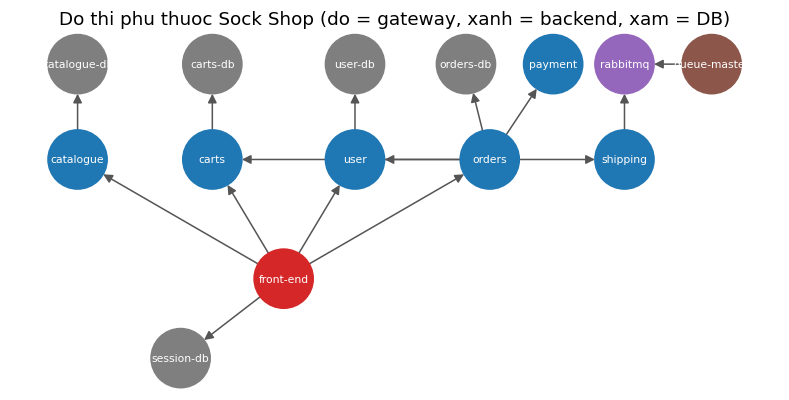

In [25]:
G = json.load(open(ROOT / 'src/graph/sockshop_agent_graph.json', encoding='utf-8'))
g = nx.DiGraph(); color = {'gateway': '#d62728', 'backend': '#1f77b4', 'database': '#7f7f7f',
                           'message_queue': '#9467bd', 'worker': '#8c564b'}
for n in G['nodes']: g.add_node(n['id'], t=n.get('type'))
for e in G['edges']: g.add_edge(e['source'], e['target'])
pos = {'front-end': (0, 0), 'session-db': (-1.3, -1), 'catalogue': (-2.6, 1.5), 'carts': (-.9, 1.5), 'user': (.9, 1.5),
       'orders': (2.6, 1.5), 'catalogue-db': (-2.6, 2.7), 'carts-db': (-.9, 2.7), 'user-db': (.9, 2.7), 'orders-db': (2.3, 2.7),
       'payment': (3.4, 2.7), 'shipping': (4.3, 1.5), 'rabbitmq': (4.3, 2.7), 'queue-master': (5.4, 2.7)}
fig, ax = plt.subplots(figsize=(9, 4.2))
nx.draw_networkx(g, pos, ax=ax, node_color=[color[g.nodes[n]['t']] for n in g], node_size=1500,
                 font_size=7, font_color='white', arrowsize=12, edge_color='#555')
ax.set_title('Do thi phu thuoc Sock Shop (do = gateway, xanh = backend, xam = DB)'); ax.axis('off'); plt.show()

Mọi request đi qua **front-end** (gateway duy nhất). `orders` là node "quạt ra" lớn nhất: một lần đặt hàng gọi
`user`, `carts`, `payment`, `shipping`.

### B3.2 SCM dùng cho dự đoán

Với tải nền `L` (req/s tại gateway) và một tính năng có tỉ lệ traffic Δ, chuỗi gọi `chain` và bội số gọi `k_s`:

$$
\underbrace{L,\ \Delta,\ \text{chain},\ k}_{\text{gốc — can thiệp } do(\cdot)}
\;\longrightarrow\; W_s \;\longrightarrow\; \text{CPU}_s = \alpha_s + \beta_s W_s
\;\longrightarrow\; u_s = \frac{\text{CPU}_s}{C_s}
\;\longrightarrow\; \text{phán quyết: } \max_s u_s \lessgtr u^*
$$

- **Workload nền:** `W_s = ρ_s · L` — ρ_s là tỉ lệ workload của service `s` so với gateway theo cơ cấu request nền.
- **Can thiệp:** tính năng mới là một phép `do(Δ, chain, k)` ở **node gốc** (traffic vào từ ngoài hệ). Vì can
  thiệp nằm ở gốc, *truncated factorisation* không cắt cạnh nào — đó là lý do toán tử `do()` không cho lợi thế
  ước lượng so với hồi quy thường (kết quả RQ4 của bài), còn **đồ thị** thì có (quyết định tải đổ vào node nào).

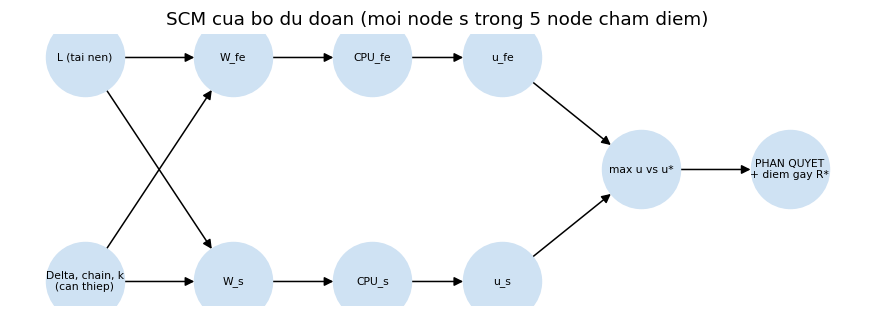

In [26]:
d = nx.DiGraph()
d.add_edges_from([('L (tai nen)', 'W_fe'), ('Delta, chain, k\n(can thiep)', 'W_fe'), ('Delta, chain, k\n(can thiep)', 'W_s'),
                  ('L (tai nen)', 'W_s'), ('W_fe', 'CPU_fe'), ('W_s', 'CPU_s'), ('CPU_fe', 'u_fe'), ('CPU_s', 'u_s'),
                  ('u_fe', 'max u vs u*'), ('u_s', 'max u vs u*'), ('max u vs u*', 'PHAN QUYET\n+ diem gay R*')])
p = {'L (tai nen)': (0, 1), 'Delta, chain, k\n(can thiep)': (0, -1), 'W_fe': (1.6, 1), 'W_s': (1.6, -1),
     'CPU_fe': (3.1, 1), 'CPU_s': (3.1, -1), 'u_fe': (4.5, 1), 'u_s': (4.5, -1), 'max u vs u*': (6, 0),
     'PHAN QUYET\n+ diem gay R*': (7.6, 0)}
fig, ax = plt.subplots(figsize=(10, 3.2))
nx.draw_networkx(d, p, ax=ax, node_size=2600, node_color='#cfe2f3', font_size=7, arrowsize=12)
ax.set_title('SCM cua bo du doan (moi node s trong 5 node cham diem)'); ax.axis('off'); plt.show()

### B3.3 Cạnh *học* được (backpressure) — có nhưng **không** dùng trong bộ dự đoán khả thi

`src/graph/sockshop_scm_edges.json` là kết quả chọn cạnh CPU→CPU giữa service (theo CausIL: chỉ cạnh được tri thức
miền cho phép, phải qua chấm điểm held-out, knee-point và kiểm OOD). Các cạnh này thuộc đường `CapacityAgent`
cũ (RQ1–RQ4); bộ dự đoán khả thi ở mục B5 **chỉ** dùng cạnh workload theo chiều gọi.

In [27]:
E = json.load(open(ROOT / 'src/graph/sockshop_scm_edges.json', encoding='utf-8'))
print('canh cuoi cung duoc giu:', E['final_edges'])
display(pd.DataFrame(E['scores']).sort_values('r2_gain', ascending=False))

canh cuoi cung duoc giu: [['orders_cpu', 'shipping_cpu'], ['orders_cpu', 'carts_cpu'], ['front-end_cpu', 'user_cpu']]


,caller,callee,r2_baseline,r2_extended,r2_gain,n_rows
0,orders,shipping,0.0008,0.1511,0.1502,63486
1,orders,carts,0.0020,0.0802,0.0783,63486
2,front-end,user,0.0215,0.0616,0.0401,63486
3,orders,user,0.0215,0.0403,0.0188,63486
4,front-end,orders,0.0858,0.0974,0.0116,63486
5,front-end,carts,0.0020,0.0121,0.0101,63486
6,front-end,catalogue,0.0000,0.0000,0.0000,63486
7,orders,payment,0.0002,0.0002,0.0000,63486


### B3.4 Chuỗi gọi: taxonomy (viết tay) so với thực tế (đo bằng probe)

Mỗi tính năng được ánh xạ **trước khi probe** vào một *archetype*; archetype mang `chain` và Δ viết tay. Sau khi
agent mù cài xong, `probe_feature_chain.py` gọi tính năng ~20 lần **khi hệ rảnh** (không dùng dữ liệu tải) và đếm
số lần mỗi backend bị gọi → **bội số `k_s`** và **chain thật**.

In [28]:
kdoc = {}
for f in ['k_measured_v3.json', 'k_measured_v4new.json']:          # v3 = 8 tinh nang vong 2, v4new = reorder/orderfull
    kdoc.update(json.load(open(FROZEN / f, encoding='utf-8'))['features'])
FEATS = ['login', 'register', 'wishlist', 'catsearch', 'account', 'preview', 'orderhist', 'related', 'reorder', 'orderfull']
rows = []
for f in FEATS:
    kf = kdoc[f]; arch = FP.FEATURE_ARCHETYPE[f]
    tax = SOCKSHOP_CALL_CHAINS[arch]['services']
    rows.append({'tinh_nang': f, 'archetype': arch, 'Delta_%': HARNESS.FEATURES[f]['anchor'],
                 'chain_taxonomy': tax, 'chain_do_duoc': kf['chain_measured'],
                 'khop?': set(tax) == set(kf['chain_measured']),
                 'k (>0)': {s: v for s, v in kf['measured_per_use'].items() if v > 0},
                 'Sum k backend': sum(v for s, v in kf['measured_per_use'].items() if s != 'front-end'),
                 'p99 luc ranh (ms)': round(1000 * kf['latency_idle']['p99'], 1) if 'latency_idle' in kf else None})
chains = pd.DataFrame(rows); display(chains)
print(f"chain taxonomy lech thuc te o {(~chains['khop?']).sum()}/{len(chains)} tinh nang")

,tinh_nang,archetype,Delta_%,chain_taxonomy,chain_do_duoc,khop?,k (>0),Sum k backend,p99 luc ranh (ms)
0,login,LOGIN,10,"[front-end, user]","[front-end, user, carts]",False,"{'front-end': 1.0, 'user': 1.0, 'carts': 1.0}",2.00,138.7
1,register,REGISTER,10,"[front-end, user]","[front-end, user, carts]",False,"{'front-end': 1.0, 'user': 1.0, 'carts': 1.0}",2.00,120.0
2,wishlist,ADD_TO_CART,15,"[front-end, catalogue, carts]","[front-end, catalogue, carts]",True,"{'front-end': 1.0, 'catalogue': 1.0, 'carts': ...",3.05,73.3
3,catsearch,GET_CATALOGUE,10,"[front-end, catalogue]","[front-end, catalogue]",True,"{'front-end': 1.0, 'catalogue': 1.0}",1.00,56.2
4,account,RECOMMEND_PRODUCTS,30,"[front-end, user, catalogue, orders]","[front-end, user, orders]",False,"{'front-end': 1.0, 'user': 3.0, 'orders': 1.0}",4.00,195.2
5,preview,VIEW_CART,10,"[front-end, carts]","[front-end, catalogue, user, carts]",False,"{'front-end': 1.0, 'catalogue': 1.0, 'user': 1...",3.00,87.2
6,orderhist,TRACK_PACKAGE,15,"[front-end, orders, shipping]","[front-end, orders]",False,"{'front-end': 1.0, 'orders': 1.0}",1.00,102.9
7,related,GET_CATALOGUE,10,"[front-end, catalogue]","[front-end, catalogue]",True,"{'front-end': 1.0, 'catalogue': 2.0}",2.00,60.2
8,reorder,PLACE_ORDER,25,"[front-end, user, catalogue, carts, orders, pa...","[front-end, catalogue, user, carts, orders, pa...",True,"{'front-end': 1.0, 'catalogue': 1.0, 'user': 6...",14.00,140.5
9,orderfull,RECOMMEND_PRODUCTS,30,"[front-end, user, catalogue, orders]","[front-end, catalogue, orders]",False,"{'front-end': 1.0, 'catalogue': 1.0, 'orders':...",2.00,78.2


chain taxonomy lech thuc te o 6/10 tinh nang


Chain viết tay **lệch thực tế ở nhiều tính năng** (vd. `login` gọi thêm `carts` để merge giỏ). Đây là *dữ liệu*,
không phải lỗi: người cài mù không biết taxonomy. Bội số `k ≠ 1` (vd. `reorder`) là nguyên nhân sai số lớn nhất
đã tìm ra ở vòng độc lập — P3 sinh ra để sửa nó.

### B3.5 Quy trình probe đo `k` (chạy trên hệ thật, **không** dùng dữ liệu tải)

Probe chạy **sau khi agent mù cài xong, trước khi đóng băng P3**, khi hệ đang rảnh:

```
python papers/p1_du_phong/experiments/collect/probe_feature_chain.py --features login,register,... \
    --n 20 --n-latency 200 --user-every 20 --save data/processed/frozen/k_measured_v2.json
```

1. Chụp bộ đếm request của từng backend (từ access-log).
2. Gọi tính năng `n = 20` lần, tuần tự.
3. `k_s` = (số request tăng thêm ở backend `s`) / 20; tách theo phương thức HTTP (`per_use_by_method`).
4. Gọi thêm 200 lần để lấy phân phối độ trễ **lúc rảnh** (`latency_idle`, dùng cho cổng nhu cầu phục vụ).

Notebook không chạy lại probe (cần hệ đang chạy và tính năng đã cài); nó đọc file probe đã lưu ở ô trên.

## B4. Cơ chế học từ dữ liệu (không có tính năng)

Với mỗi service `s`, từ `SS-TRAIN` (không trần CPU, bỏ bậc khởi động, tải ≤ 150 req/s):

- `ρ_s` = hồi quy qua gốc của `W_s` theo `W_gateway` → cơ cấu request nền.
- `CPU_s = α_s + β_s · W_s` bằng **NNLS** (α, β ≥ 0) → chi phí CPU mỗi request.

Ô dưới **fit lại từ đầu** rồi so với cơ chế trong file đã đóng băng — nếu khớp, chuỗi tái lập được.

In [29]:
P2F = json.load(open(FROZEN / 'predictions_frozen_RE2_P2_prosp2.json', encoding='utf-8'))
mech_frozen = P2F['mechanism']
train = FP.select_train(FP.load_runs(str(RAW / 'SS-TRAIN')), P2F['params']['train_max_rps'])
mech_refit = FP.fit_mechanism(train)
m = pd.DataFrame(mech_frozen).T[['rho', 'alpha', 'beta', 'r2', 'n', 'w_max_train']]
m['beta_fit_lai'] = [mech_refit[s]['beta'] for s in m.index]
m['khop'] = np.isclose(m['beta'], m['beta_fit_lai'], rtol=1e-3)
display(m.round(4))

,rho,alpha,beta,r2,n,w_max_train,beta_fit_lai,khop
carts,0.3948,0.0968,0.1752,0.9644,456.0,82.5999,0.1752,True
catalogue,0.5702,0.0582,0.0548,0.9954,456.0,103.3991,0.0548,True
front-end,1.0000,1.1188,0.2071,0.9890,456.0,186.9998,0.2071,True
orders,0.0350,0.1601,0.5804,0.9640,456.0,8.0016,0.5804,True
payment,0.0350,0.0334,0.0306,0.8115,456.0,8.0016,0.0306,True
shipping,0.0350,0.1733,0.0924,0.4711,456.0,8.0016,0.0924,True
user,0.3257,0.0525,0.0673,0.9935,456.0,70.8000,0.0673,True


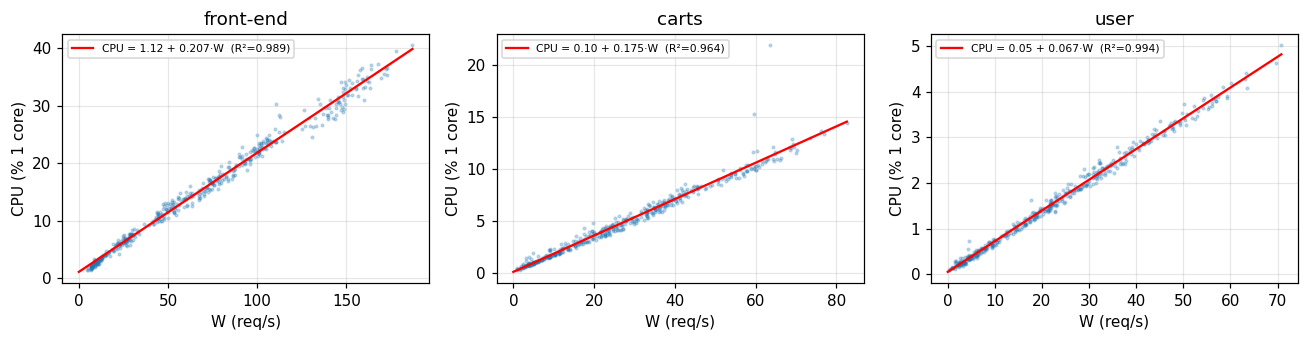

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, s in zip(axes, ['front-end', 'carts', 'user']):
    ax.scatter(train[f'{s}_workload'], train[f'{s}_cpu'], s=3, alpha=.25)
    w = np.linspace(0, train[f'{s}_workload'].max(), 50); mm = mech_frozen[s]
    ax.plot(w, mm['alpha'] + mm['beta'] * w, 'r-', label=f"CPU = {mm['alpha']:.2f} + {mm['beta']:.3f}·W  (R²={mm['r2']:.3f})")
    ax.set_title(s); ax.set_xlabel('W (req/s)'); ax.set_ylabel('CPU (% 1 core)'); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

Cơ chế tuyến tính khớp rất tốt **trong dải huấn luyện** (R² ≈ 0,99 ở front-end). Lưu ý: dữ liệu huấn luyện
**không có trần CPU**, còn dự đoán áp dụng dưới trần RE2 — đó là ngoại suy chế độ vận hành (Phần C, M4).

### B4.1 Ngưỡng u*

`u*` = mức sử dụng của node nghẽn ở **bậc đạt SLO cuối cùng** trong các ramp `base` (trung vị), chỉ đọc ramp không
có tính năng:

In [31]:
# freeze_predictions.py con kiem CO CHE tren DU LIEU GIU LAI (tai > train_max) va luu ket qua vao file dong bang
display(pd.DataFrame(P2F['mechanism_check_holdout']).T if isinstance(P2F['mechanism_check_holdout'], dict)
        else pd.DataFrame(P2F['mechanism_check_holdout']))

,level,measured,predicted,rel_err_pct,service
0,200.0,41.404,42.651,3.0,front-end
1,200.0,6.318,6.325,0.1,catalogue
2,200.0,4.499,4.398,-2.2,user
3,200.0,13.956,13.925,-0.2,carts
4,200.0,4.304,4.160,-3.3,orders
5,250.0,50.167,52.870,5.4,front-end
6,250.0,7.969,7.847,-1.5,catalogue
7,250.0,5.720,5.544,-3.1,user
8,250.0,17.727,17.480,-1.4,carts
9,250.0,5.519,5.236,-5.1,orders


### B4.1 Hiệu chỉnh ngưỡng u* — làm lại từ đầu

Quy trình (`calibrate_u_star`): với mỗi ramp **base** của `SS-LIMITS` (chỉ ramp không có tính năng — hàm từ chối nếu
gặp ramp tính năng), lấy bậc đạt SLO cuối cùng `lo`, tính mức sử dụng trung bình mỗi node ở bậc đó (bỏ giây khởi
động), lấy node cao nhất. `u*` = trung vị qua các ramp. Ô dưới tính lại và so với file đóng băng; sau đó áp **cùng
quy trình** lên các ramp `base` của `SS-PROSP2` để thấy u* của phiên đo tiến cứu.

In [32]:
import re
def u_star_from(ramp_root, cores_, only_plain=True):
    vals = []
    for sp in sorted((bo(ramp_root) / 'ramp_base').glob('run*/steps.json')):
        if only_plain and not re.fullmatch(r'run\d+', sp.parent.name):
            continue
        jj = json.load(open(sp, encoding='utf-8')); lo = jj['breakpoint']['lo']
        d_ = pd.read_csv(sp.parent / 'simple_metrics.csv')
        d_ = d_.rename(columns={c: c[3:] for c in d_.columns if c.startswith('gt_')})
        d_ = d_[(d_['step_warm'] == 0) & (d_['target_rps'] == lo)]
        u_ = {s: d_[f'{s}_cpu'].mean() / (100 * cores_[s]) for s in FP.SCORED}
        b_ = max(u_, key=u_.get); vals.append({'ramp': sp.parent.name, 'lo': lo, 'nut nghen': b_, 'u': round(u_[b_], 4)})
    return pd.DataFrame(vals)

cal_limits = u_star_from('SS-LIMITS', P2F['params']['cores'])
cal_prosp = u_star_from('SS-PROSP2', P2F['params']['cores'])
display(cal_limits)
print(f"u* tinh lai (SS-LIMITS, 3 ramp goc) = {cal_limits.u.median():.4f}  |  trong file dong bang = {P2F['params']['u_star']}")
extra = u_star_from('SS-LIMITS', P2F['params']['cores'], only_plain=False)
extra = extra[~extra.ramp.str.fullmatch(r'run\d+')]
print('2 ramp base DO THEM sau (Pha B, KHONG dung de hieu chinh):'); display(extra)
print(f"cung quy trinh tren {len(cal_prosp)} ramp base cua SS-PROSP2: u* = {cal_prosp.u.median():.4f} "
      f"(khoang {cal_prosp.u.min():.3f}-{cal_prosp.u.max():.3f})")

,ramp,lo,nut nghen,u
0,run1,220,front-end,0.8421
1,run2,220,front-end,0.8870
2,run3,220,front-end,0.8783


u* tinh lai (SS-LIMITS, 3 ramp goc) = 0.8783  |  trong file dong bang = 0.8783
2 ramp base DO THEM sau (Pha B, KHONG dung de hieu chinh):


,ramp,lo,nut nghen,u
1,run1_20260921_223835,160,front-end,0.7073
3,run2_20260921_223835,160,front-end,0.6772


cung quy trinh tren 8 ramp base cua SS-PROSP2: u* = 0.8031 (khoang 0.687-0.856)


u* đóng băng dùng đúng 3 ramp `base` gốc (`run1–3`, điểm gãy 220). Hai ramp `base` đo thêm trong Pha B vỡ ở 160
với u ≈ 0,68–0,71 — dấu hiệu sớm của hiện tượng trôi hệ thống. Nếu u* của phiên tiến cứu thấp hơn 0,878 thì ngưỡng
đóng băng đã **quá lạc quan** cho phiên đó — khớp với chẩn đoán
ở mục B7 (SLO vỡ khi front-end mới ở u ≈ 0,70–0,80). *Chỉ dùng để chẩn đoán:* đổi u* bây giờ là phát triển, không phải
tiến cứu.

## B5. Bốn mô hình dự đoán

Tất cả dùng chung cơ chế ở mục B4, chỉ khác cách đổ tải tính năng vào `W_s`:

| Mô hình | Workload của tính năng | Ý tưởng |
|---|---|---|
| **P0** | `W_s = ρ_s·L·(1+Δ)` | tăng đều mọi node theo cơ cấu nền (hành vi `CapacityAgent` cũ) |
| **P1** | `W_s = L·(ρ_s + Δ·k_s·[s∈chain])`, k = 1 | chỉ node trong chain nhận thêm tải |
| **P1_ctrl** | như P1 nhưng chain **ngẫu nhiên** cùng cỡ | đối chứng: chain có giá trị thật không? |
| **P2** | backend: `+Δ·k_s·c_s`; gateway: `+Δ·(1 + x·Σk)` | thêm chi phí mỗi lần gọi `c_s` và chi phí điều phối gateway `x`, **fit trên promo/recs** |
| **P3** | như P2 nhưng `k_s` **đo bằng probe** | sửa giả định mỗi hop gọi đúng 1 lần |

Vì mọi thứ tuyến tính theo `L`, điểm gãy có **dạng đóng**: với mỗi node,
`L_s = (u*·C_s − α_s) / (β_s · W_s(L=1))`, và `R* = min_s L_s`.

Tham số P2 đã đóng băng:

In [33]:
p2 = P2F['p2_params']
print('c_s (chi phi moi lan goi so voi request nen):', {k: round(v, 3) for k, v in p2['c'].items()})
print('x (chi phi dieu phoi gateway / moi lan goi backend):', round(p2['x'], 4))
P = FP.FeasibilityPredictor(mech_frozen, P2F['params']['cores'], P2F['params']['u_star'], feature_cost=p2)

c_s (chi phi moi lan goi so voi request nen): {'carts': 1.513, 'catalogue': 1.065, 'orders': 0.436, 'user': 1.311}
x (chi phi dieu phoi gateway / moi lan goi backend): 0.3685


### B5.0 Quy trình fit tham số P2 (`c_s`, `x`) — làm lại từ đầu

`papers/p1_du_phong/experiments/feasibility/fit_feature_costs.py`, **chỉ trên tập phát triển** (ramp `promo`, `recs` của `SS-LIMITS`;
không đọc tập khoá `track`/`review`). Cơ chế nền, trần, u* lấy nguyên từ bản đóng băng gốc.

1. Với mỗi bậc tải **trước điểm gãy** và mỗi node: đo `W_s`, `CPU_s` thật.
2. **`c_s`** (backend trong chain) = CPU tăng thêm do tính năng ÷ (β_s × workload tăng thêm **đo được**) → chi phí **mỗi
   lần gọi** so với request nền (tách khỏi bội số `k`).
3. **`x`** (gateway): mỗi request tính năng tốn `(1 + x·n_calls)` lần một request nền; hồi quy qua gốc.

In [34]:
import evaluate_frozen as EF, fit_feature_costs as FFC
FZ0 = json.load(open(FROZEN / 'predictions_frozen_RE2.json', encoding='utf-8'))
preds0 = {(p['predictor'], p['feature'], round(float(p['scale']), 3)): p for p in FZ0['predictions']}
with quiet():
    runs_dev = EF.load_ramps(str(RAW / 'SS-LIMITS'), EF.DEV)
rows_dev = FFC.build_rows(runs_dev, FZ0['mechanism'], FZ0['params']['cores'], preds0)
fit = FP.fit_feature_cost(rows_dev, FZ0['mechanism'])
saved = json.load(open(FROZEN / 'p2_params_dev.json', encoding='utf-8'))['params']
print(f"{len(runs_dev)} ramp phat trien, {len(rows_dev)} dong (buoc tai x node)")
display(pd.DataFrame({'fit lai': {**fit['c'], 'x': fit['x']}, 'file dong bang': {**saved['c'], 'x': saved['x']}}).round(4))
print('boi so chi phi gateway theo tinh nang:', {k: round(v, 3) for k, v in fit['gateway_multiple_by_feature'].items()},
      '| n_calls:', rows_dev.groupby('feature').n_calls.first().to_dict())

13 ramp phat trien, 185 dong (buoc tai x node)


,fit lai,file dong bang
carts,1.5126,1.5126
catalogue,1.0650,1.0650
orders,0.4360,0.4360
user,1.3112,1.3112
x,0.3685,0.3685


boi so chi phi gateway theo tinh nang: {'promo': 2.055, 'recs': 2.218} | n_calls: {'promo': 3, 'recs': 3}


**Điểm yếu thấy ngay (M2):** cả hai tính năng phát triển đều có `n_calls = 3`, nên `x` được xác định từ **một** giá trị
`n_calls` duy nhất — dạng `1 + x·n_calls` không hề được kiểm; bất kỳ dạng nào đi qua điểm `n_calls = 3` đều fit như nhau.

### B5.1 Một phán quyết giải trình đầy đủ: `login` ở 150 req/s (P3)

`explain_text()` phơi bày từng bước tính — không tính lại gì ngoài chính `workloads()`/`cpu()`/`verdict()`.

In [35]:
k_login = kdoc['login']['measured_per_use']
print(P.explain_text(150, mode='P2', feature='login', k=k_login))

Yeu cau 'login' o tai nen L = 150 req/s  (che do P2)
  Delta = 0.100 (tinh nang them 10.0% tai so voi nen)
  chain = ['front-end', 'user']
  boi so goi k: do bang probe

  service        W nen  +tinh nang      = W     CPU  / tran     = u
  front-end      150.0        20.5    170.5   36.44      50   0.729 !
  catalogue       85.5         0.0     85.5    4.74      50   0.095
  user            48.9        19.7     68.5    4.67      20   0.233
  carts           59.2         0.0     59.2   10.47      50   0.209
  orders           5.2         0.0      5.2    3.21      50   0.064

  ! nut nghen = front-end voi u = 0.729; nguong u* = 0.878
  => PHAN QUYET: FEASIBLE
     · front-end: gateway: moi request di qua + chi phi dieu phoi x=0.368 x Sum k=1
     · user: trong chain: Delta=0.100 x k=1 x c_s=1.311


### B5.2 Điểm gãy dạng đóng — nhìn bằng hình

Đường `u_s(L)` của từng node là **đường thẳng**; điểm gãy là chỗ đường cao nhất chạm `u*`.

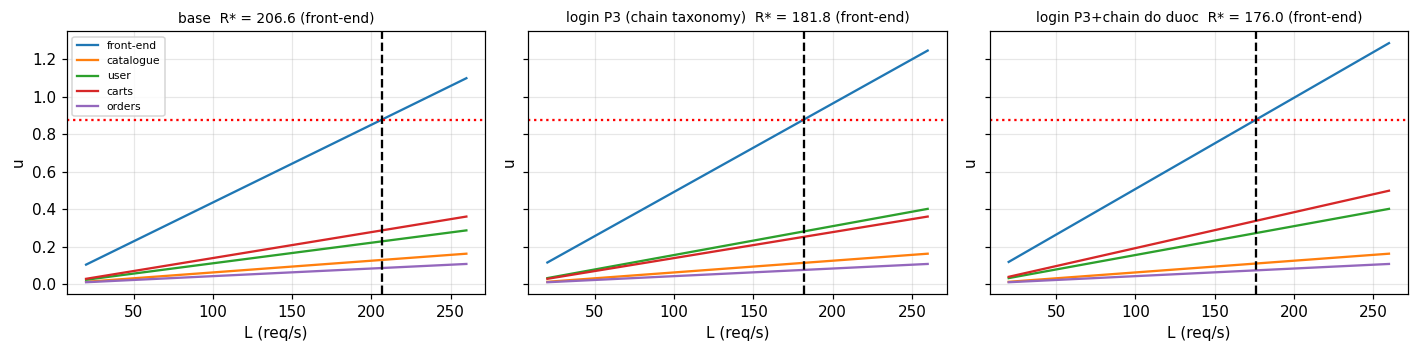

In [36]:
def plot_u(feature, k=None, chain=None, ax=None, title=''):
    Ls = np.linspace(20, 260, 60)
    for s in FP.SCORED:
        ax.plot(Ls, [P.utilization(L, mode='P2', feature=feature, k=k, chain=chain)[s] for L in Ls], label=s)
    r, node = P.breakpoint(mode='P2', feature=feature, k=k, chain=chain)
    ax.axhline(P.u_star, color='red', ls=':'); ax.axvline(r, color='k', ls='--')
    ax.set_title(f'{title}  R* = {r:.1f} ({node})', fontsize=9); ax.set_xlabel('L (req/s)'); ax.set_ylabel('u')
    return r

fig, axes = plt.subplots(1, 3, figsize=(13, 3.3), sharey=True)
plot_u('base', ax=axes[0], title='base')
plot_u('login', k=k_login, ax=axes[1], title='login P3 (chain taxonomy)')
plot_u('login', k=k_login, chain=kdoc['login']['chain_measured'], ax=axes[2], title='login P3+chain do duoc')
axes[0].legend(fontsize=7); plt.tight_layout(); plt.show()

> ⚠️ **Điều cần biết về P3 đã đóng băng.** `freeze_p3_prospective.py` gọi `breakpoint(mode='P2', k=k)` **không
> truyền `chain`**, nên P3 dùng **chain của taxonomy**; node ngoài chain taxonomy (vd. `carts` của `login`) không
> nhận tải dù `k = 1`. Trong khi đó trường `chain` ghi trong file đóng băng lại là `chain_measured`. Con số đóng
> băng (181,8) là đúng với code đã băm — chỉ nhãn trong file dễ đọc nhầm. Biến thể dùng chain đo được là
> **P3+chain** (hồi cứu, cột riêng trong `evaluate_p3.py`). Ô dưới kiểm chứng:

In [37]:
chk = []
for f in FEATS:
    fz = json.load(open(FROZEN / f'predictions_frozen_RE2_P3_prosp_{f}.json', encoding='utf-8'))
    frozen_r = next(p['breakpoint_rps'] for p in fz['predictions'] if p['scale'] == 1.0)
    k = kdoc[f]['measured_per_use']
    r_tax, _ = P.breakpoint(mode='P2', feature=f, k=k)
    r_meas, _ = P.breakpoint(mode='P2', feature=f, k=k, chain=kdoc[f]['chain_measured'])
    chk.append({'tinh_nang': f, 'P3 dong bang': frozen_r, 'tinh lai (chain taxonomy)': round(r_tax, 1),
                'P3+chain do duoc': round(r_meas, 1)})
chk = pd.DataFrame(chk); display(chk)
assert (chk['P3 dong bang'] == chk['tinh lai (chain taxonomy)']).all(), 'KHONG tai lap duoc P3 dong bang!'
print('OK: tai lap bit-for-bit P3 dong bang cho ca 10 tinh nang')

,tinh_nang,P3 dong bang,tinh lai (chain taxonomy),P3+chain do duoc
0,login,181.8,181.8,176.0
1,register,181.8,181.8,176.0
2,wishlist,156.7,156.7,156.7
3,catsearch,181.8,181.8,181.8
4,account,118.6,118.6,118.6
5,preview,181.8,181.8,170.7
6,orderhist,171.4,171.4,171.4
7,related,176.0,176.0,176.0
8,reorder,81.4,81.4,81.4
9,orderfull,135.8,135.8,135.8


OK: tai lap bit-for-bit P3 dong bang cho ca 10 tinh nang


### B5.3 Đóng băng — và kiểm tính toàn vẹn

Quy tắc bất khả xâm phạm: **agent mù cài → probe → đóng băng + băm SHA-256 → (commit git) → mới được chạy ramp**. Các
script đóng băng có chốt chặn: từ chối nếu thư mục ramp đã có dữ liệu của tính năng; từ chối nếu thiếu ánh xạ
archetype; bắt buộc `--p2-params` cho bộ tính năng mới. Mỗi file đóng băng ghi kèm SHA-256 của chính code dự đoán.

Ô dưới băm lại **mọi file đóng băng** và so với file `.sha256` đi kèm, rồi tra thời điểm git đầu tiên thấy file.

In [38]:
import hashlib, subprocess
def sha(p): return hashlib.sha256(open(p, 'rb').read()).hexdigest()
def first_commit(p):
    r = subprocess.run(['git', 'log', '--diff-filter=A', '--format=%ci %h', '--', str(p.relative_to(ROOT))],
                       capture_output=True, text=True, cwd=ROOT).stdout.strip().splitlines()
    return r[-1] if r else '(chua commit)'
rows = []
for f in sorted(FROZEN.glob('predictions_frozen_*.json')):
    s = f.with_name(f.name + '.sha256')
    rec = open(s).read().split()[0] if s.exists() else None
    created = json.load(open(f, encoding='utf-8')).get('created')
    rows.append({'file': f.name, 'tao luc': created, 'git lan dau': first_commit(f),
                 'SHA khop .sha256?': (sha(f) == rec) if rec else 'khong co .sha256'})
integ = pd.DataFrame(rows); display(integ)
print('so file KHONG khop:', int((integ['SHA khop .sha256?'] == False).sum()))

,file,tao luc,git lan dau,SHA khop .sha256?
0,predictions_frozen_RE2.json,2026-09-21 22:34:16,2026-09-21 22:41:25 +0700 d42214b,True
1,predictions_frozen_RE2_P2.json,2026-09-22 06:18:49,2026-09-22 07:12:32 +0700 0ede97c,True
2,predictions_frozen_RE2_P2_indep.json,2026-09-22 06:34:45,2026-09-22 07:12:32 +0700 0ede97c,True
3,predictions_frozen_RE2_P2_prosp.json,2026-09-22 12:07:05,2026-09-22 16:19:10 +0700 5bce34b,True
4,predictions_frozen_RE2_P2_prosp2.json,2026-09-25 15:51:22,2026-09-26 23:44:27 +0700 046d55d,True
5,predictions_frozen_RE2_P2_prosp3.json,2026-09-25 19:08:53,2026-09-26 23:44:27 +0700 046d55d,True
6,predictions_frozen_RE2_P2_prosp4.json,2026-09-25 22:00:14,2026-09-26 23:44:27 +0700 046d55d,True
7,predictions_frozen_RE2_P3_prosp_account.json,2026-09-25 15:51:32,2026-09-26 23:44:27 +0700 046d55d,False
8,predictions_frozen_RE2_P3_prosp_browse.json,2026-09-22 12:12:50,2026-09-22 16:19:10 +0700 5bce34b,False
9,predictions_frozen_RE2_P3_prosp_catsearch.json,2026-09-25 15:51:32,2026-09-26 23:44:27 +0700 046d55d,False


so file KHONG khop: 11


**Đọc bảng:** mọi file khớp hash — nội dung không bị sửa kể từ lúc băm. Nhưng hãy so cột `git lần đầu` với ngày đo:
các file của vòng tiến cứu 2 (`prosp2`, `prosp3`, `prosp4`, `P3_prosp_*` trừ `browse`) được git thấy **lần đầu lúc
26/09 23:44**, tức **sau** khi ramp đã chạy (25–26/09). Các commit đóng băng gốc tạo trước ramp đã bị gỡ bằng
`git reset --soft` và không còn trong repo. Hash chứng minh nội dung không đổi, nhưng **không** chứng minh thời điểm;
trường `created` là tự khai. Với vòng 2, bằng chứng thời điểm độc lập hiện chỉ còn nhật ký làm việc trong `docs/`.
Vòng sau: commit file đóng băng **và push** (hoặc gửi hash cho bên thứ ba) trước khi chạy ramp.

### B5.4 Agent sản phẩm: `NewFeatureFeasibilityAgent.assess()`

Đây là thứ `orchestrator.assess(...)` gọi thật. Nó thêm ba lớp quanh bộ dự đoán:

1. **Trần CPU sống:** đọc giới hạn thật từ `docker inspect` (dự phòng `limits.json`).
2. **Khoảng bất định bootstrap:** lấy mẫu lại **dữ liệu huấn luyện gốc**, fit lại cơ chế B lần, tính lại điểm gãy.
3. **Cổng throttling:** nếu node nghẽn có hạn ngạch < 0,5 core (vùng CFS throttling đã thấy ở C1/C2) → trả
   **`UNDECIDED`**, không đoán một con số.

(Cờ `latency_risk` = Σk ≥ 4 là cổng nhu cầu phục vụ đã **thất bại** khi kiểm tiến cứu — giữ để minh bạch.)

In [39]:
from feasibility_agent import NewFeatureFeasibilityAgent
fa = NewFeatureFeasibilityAgent()
with quiet():
    v = fa.assess('login', L_peak=150, k=kdoc['login']['measured_per_use'], n_bootstrap=60)
display(pd.Series({k: val for k, val in v.__dict__.items() if k != 'utilization_by_node'}).to_frame('login @ 150 req/s'))
print('muc su dung theo node:', v.utilization_by_node)

,login @ 150 req/s
verdict,FEASIBLE
breakpoint_rps,181.9
breakpoint_ci,"(180.6, 183.3)"
bottleneck,front-end
max_utilization,0.7288
extrapolating,False
extrap_nodes,[]
latency_risk,False
throttling_risk,False
bottleneck_cores,0.5


muc su dung theo node: {'front-end': 0.7288, 'catalogue': 0.0948, 'user': 0.2334, 'carts': 0.2094, 'orders': 0.0641, 'payment': 0.0194, 'shipping': 0.0132}


## B6. Kết quả tiến cứu n = 10

**Đáp án** của mỗi ô = trung vị `lo` qua các lần lặp (cường độ ×1). Hai mốc nền **không dùng đồ thị nào**:

- `const_base`: đoán mọi tính năng vỡ ở đúng điểm gãy của baseline (bỏ qua tính năng).
- `const_oracle`: hằng số **tốt nhất có thể** = trung vị của chính các đáp án — mốc *gian lận*, dùng làm cận dưới
  cho mọi mô hình hằng số. Thắng nó mới đáng kể.

Dự đoán lấy từ file đóng băng: P1/P2 ở `P2_prosp2` / `prosp3` / **`prosp4`**, P3 ở từng file `P3_prosp_<f>`.

In [40]:
def measured(ramp_dir, feats):
    cells = {}
    for sp in sorted(bo(ramp_dir).glob('ramp_*/run*/steps.json')):
        jj = json.load(open(sp, encoding='utf-8')); f = jj.get('feature', 'base')
        if f != 'base' and (f not in feats or round(jj['feature_pct'] / HARNESS.FEATURES[f]['anchor'], 3) != 1.0):
            continue
        cells.setdefault(f, []).append(jj['breakpoint']['lo'])
        HI.setdefault(f, []).append(jj['breakpoint']['hi'] or 1.25 * jj['breakpoint']['lo'])
    return cells

HI = {}

def frozen_preds(feats):
    out = {}
    for tag in ('prosp2', 'prosp3', 'prosp4'):
        for pr in json.load(open(FROZEN / f'predictions_frozen_RE2_P2_{tag}.json', encoding='utf-8'))['predictions']:
            if pr['feature'] in feats and pr['scale'] == 1.0:
                out.setdefault(pr['feature'], {})[pr['predictor']] = pr['breakpoint_rps']
    for f in feats:
        fz = json.load(open(FROZEN / f'predictions_frozen_RE2_P3_prosp_{f}.json', encoding='utf-8'))
        out[f]['P3'] = next(p['breakpoint_rps'] for p in fz['predictions'] if p['scale'] == 1.0)
    return out

cells = measured('SS-PROSP2', FEATS); pr = frozen_preds(FEATS)
base_lo = float(np.median(cells['base'])); meas = {f: float(np.median(cells[f])) for f in FEATS}
oracle = float(np.median(list(meas.values())))
res = pd.DataFrame([{'o': f, 'dap_an': meas[f], 'lan_lap': cells[f], 'P1': pr[f].get('P1'), 'P2': pr[f].get('P2'),
                     'P3': pr[f]['P3'], 'P3+chain': chk.set_index('tinh_nang').loc[f, 'P3+chain do duoc'],
                     'const_base': base_lo, 'const_oracle': oracle} for f in FEATS]).set_index('o')
MODELS = ['P1', 'P2', 'P3', 'P3+chain', 'const_base', 'const_oracle']
err = pd.DataFrame({mdl: 100 * (res[mdl] - res['dap_an']) / res['dap_an'] for mdl in MODELS})
print(f'baseline do duoc = {base_lo:g} req/s ({len(cells["base"])} ramp) | const_oracle = {oracle:g}')
display(res)
print('\nsai so co dau (%) -- DUONG = du doan MUON hon thuc te = KHA THI GIA (nguy hiem):')
display(err.round(1))

baseline do duoc = 195 req/s (8 ramp) | const_oracle = 155


,dap_an,lan_lap,P1,P2,P3,P3+chain,const_base,const_oracle
o,,,,,,,,
login,155.0,"[125, 155, 155, 155]",187.8,181.8,181.8,176.0,195.0,155.0
register,155.0,"[125, 155, 155, 195]",187.8,181.8,181.8,176.0,195.0,155.0
wishlist,140.0,"[125, 155, 155, 125]",179.7,163.9,156.7,156.7,195.0,155.0
catsearch,195.0,"[195, 195, 195, 195]",187.8,181.8,181.8,181.8,195.0,155.0
account,125.0,"[155, 100, 125, 125]",158.9,126.6,118.6,118.6,195.0,155.0
preview,175.0,"[195, 155, 155, 195]",187.8,181.8,181.8,170.7,195.0,155.0
orderhist,155.0,"[155, 155, 195, 155]",179.7,163.9,171.4,171.4,195.0,155.0
related,175.0,"[195, 155, 195, 155]",187.8,181.8,176.0,176.0,195.0,155.0
reorder,100.0,"[100, 100, 100]",165.3,114.6,81.4,81.4,195.0,155.0



sai so co dau (%) -- DUONG = du doan MUON hon thuc te = KHA THI GIA (nguy hiem):


,P1,P2,P3,P3+chain,const_base,const_oracle
o,,,,,,
login,21.2,17.3,17.3,13.5,25.8,0.0
register,21.2,17.3,17.3,13.5,25.8,0.0
wishlist,28.4,17.1,11.9,11.9,39.3,10.7
catsearch,-3.7,-6.8,-6.8,-6.8,0.0,-20.5
account,27.1,1.3,-5.1,-5.1,56.0,24.0
preview,7.3,3.9,3.9,-2.5,11.4,-11.4
orderhist,15.9,5.7,10.6,10.6,25.8,0.0
related,7.3,3.9,0.6,0.6,11.4,-11.4
reorder,65.3,14.6,-18.6,-18.6,95.0,55.0


In [41]:
summary = pd.DataFrame({'|sai so| TB %': err.abs().mean(), 'trung vi %': err.abs().median(), 'xau nhat %': err.abs().max(),
                        'kha thi gia (du doan > hi)': [int(sum(res[mdl][f] > np.median(HI[f]) for f in FEATS)) for mdl in MODELS]})
print('KHA THI GIA = du doan vuot trung vi hi (bac dau vi pham): he DA vo ma mo hinh van bao dat')
display(summary.round(1))

from scipy import stats
for a_, b_ in [('P3', 'const_base'), ('P3', 'const_oracle'), ('P2', 'P3'), ('P3', 'P3+chain')]:
    w = stats.wilcoxon(err[a_].abs(), err[b_].abs())
    print(f'Wilcoxon |sai so| {a_:9s} vs {b_:13s}: p = {w.pvalue:.4f}')

KHA THI GIA = du doan vuot trung vi hi (bac dau vi pham): he DA vo ma mo hinh van bao dat


,|sai so| TB %,trung vi %,xau nhat %,kha thi gia (du doan > hi)
P1,21.1,18.5,65.3,3
P2,9.7,8.2,17.3,0
P3,9.5,8.7,18.6,0
P3+chain,8.6,8.7,18.6,0
const_base,33.0,25.8,95.0,4
const_oracle,14.4,11.1,55.0,1


Wilcoxon |sai so| P3        vs const_base   : p = 0.0039
Wilcoxon |sai so| P3        vs const_oracle : p = 0.4922
Wilcoxon |sai so| P2        vs P3           : p = 0.7532
Wilcoxon |sai so| P3        vs P3+chain     : p = 0.1025


### B6.1 Sàn nhiễu — vì sao chưa kết luận được "mô hình nào tốt hơn"

Cùng một ô đo 3–4 lần, `lo` thường lệch **một bậc lưới** (lưới hình học ×1,25 → một bậc ≈ 25%). Nếu sai số mô
hình nhỏ hơn biên độ lặp lại, dữ liệu **không đủ phân giải** để xếp hạng mô hình.

> ⚠️ Sàn tính ở ô dưới chỉ là độ trải **trong một phiên đo** (`SS-PROSP2`). Sàn thật rộng hơn
> gấp ~2 lần: 21,4% → 45,2% khi tính cả các phiên đo lại (`SS-PROSP2-R2/R3`, `SS-PROSP4*`), và
> 4/10 tính năng **đổi đáp án**. Năng lực *cơ sở* — không có tính năng nào, nên mọi phiên phải
> cho cùng một số — trải 120–240 req/s qua 16 phiên. Phép đo đầy đủ ở
> [notebook 02, mục 6b](02_quy_trinh_he_thong_va_thuc_nghiem.ipynb). Đọc mọi con số dưới đây
> với giới hạn đó: chúng đúng cho *một phiên*, không phải thuộc tính của mô hình.

san nhieu (trung vi bien do lap) = 21.4%  |  |sai so| TB cua P3 = 9.5%


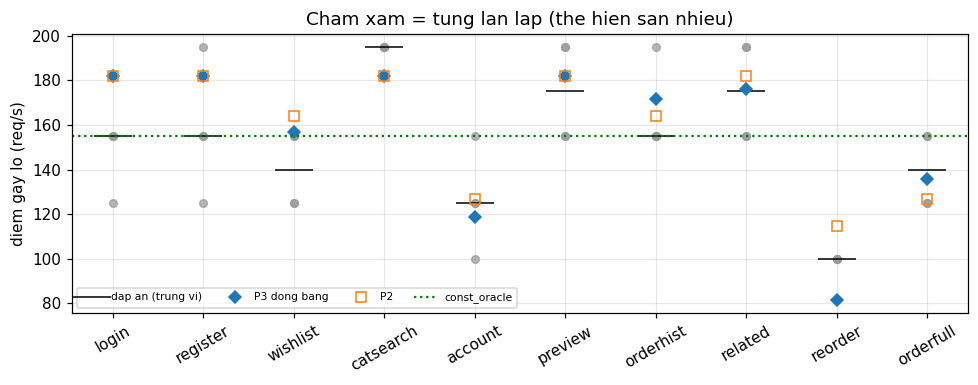

In [42]:
noise = pd.Series({f: 100 * (max(v) - min(v)) / np.median(v) for f, v in cells.items()}, name='bien do lap %')
print(f"san nhieu (trung vi bien do lap) = {noise.median():.1f}%  |  |sai so| TB cua P3 = {err['P3'].abs().mean():.1f}%")

fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(FEATS))
for i, f in enumerate(FEATS):
    ax.plot([i] * len(cells[f]), cells[f], 'o', color='#999', ms=5, alpha=.7)
ax.plot(x, res['dap_an'], '_', ms=25, color='k', label='dap an (trung vi)')
ax.plot(x, res['P3'], 'D', color='#1f77b4', label='P3 dong bang')
ax.plot(x, res['P2'], 's', color='#ff7f0e', mfc='none', label='P2')
ax.axhline(oracle, color='green', ls=':', label='const_oracle')
ax.set_xticks(x, FEATS, rotation=30); ax.set_ylabel('diem gay lo (req/s)'); ax.legend(fontsize=7, ncol=4)
ax.set_title('Cham xam = tung lan lap (the hien san nhieu)'); plt.tight_layout(); plt.show()

## B7. Chẩn đoán: mô hình sai ở node nào?

So **mức sử dụng đo được** từng node (trung bình mỗi bậc, bỏ giây khởi động) với **dự đoán** của P3 ở cùng mức
tải. Nếu sai số tập trung ở front-end thì vấn đề là chi phí gateway (M1); nếu ở backend thì là `c_s`/`k`.

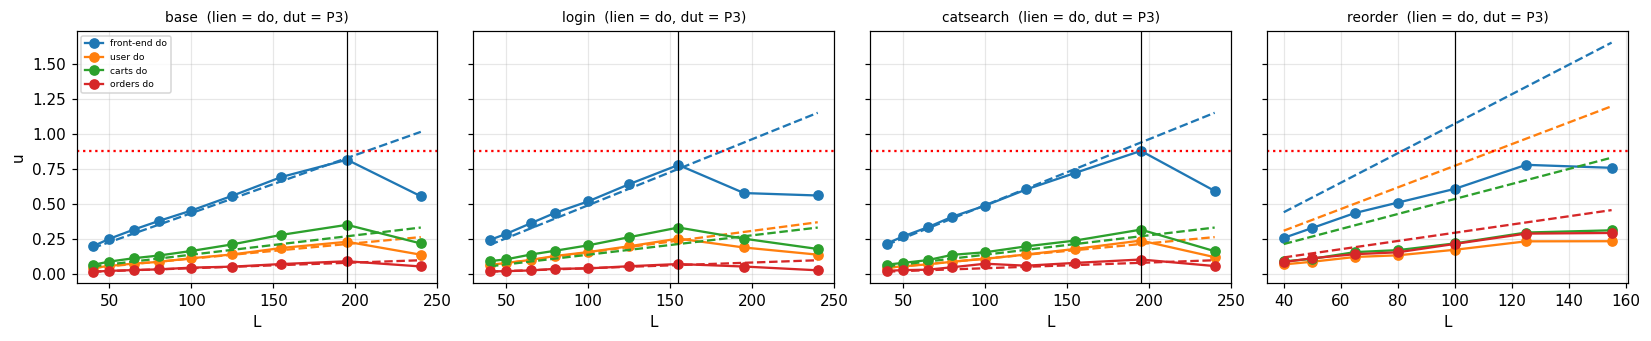

In [43]:
def measured_u(feature, ramp_dir='SS-PROSP2'):
    out = []
    thu_muc = bo(ramp_dir) / (f'ramp_{feature}_x1' if feature != 'base' else 'ramp_base')
    for p in sorted(thu_muc.glob('run*/simple_metrics.csv')):
        dd = pd.read_csv(p); dd = dd[dd['gt_step_warm'] == 0]
        g_ = dd.groupby('gt_target_rps')[[f'{s}_cpu' for s in FP.SCORED]].mean()
        g_.columns = FP.SCORED; out.append(g_ / pd.Series(cap))
    return pd.concat(out).groupby(level=0).mean()

def compare(feature):
    mu = measured_u(feature); k = kdoc[feature]['measured_per_use'] if feature != 'base' else None
    pu = pd.DataFrame({L: P.utilization(L, mode='P2', feature=feature, k=k) for L in mu.index}).T[FP.SCORED]
    return mu, pu

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2), sharey=True)
for ax, f in zip(axes, ['base', 'login', 'catsearch', 'reorder']):
    mu, pu = compare(f)
    for s, c in zip(['front-end', 'user', 'carts', 'orders'], ['C0', 'C1', 'C2', 'C3']):
        ax.plot(mu.index, mu[s], 'o-', color=c, label=f'{s} do'); ax.plot(pu.index, pu[s], '--', color=c)
    ax.axhline(P.u_star, color='red', ls=':'); ax.axvline(meas.get(f, base_lo), color='k', lw=.8)
    ax.set_title(f'{f}  (lien = do, dut = P3)', fontsize=9); ax.set_xlabel('L')
axes[0].set_ylabel('u'); axes[0].legend(fontsize=6); plt.tight_layout(); plt.show()

In [44]:
# sai so muc su dung (diem %) o front-end va node backend lon nhat, cac bac TRUOC diem gay
rows = []
for f in ['base'] + FEATS:
    mu, pu = compare(f); lim = meas.get(f, base_lo); mu, pu = mu[mu.index <= lim], pu[pu.index <= lim]
    e = 100 * (pu - mu)
    rows.append({'o': f, 'front-end (du - do)': e['front-end'].mean(),
                 'backend lech nhat': e.drop(columns='front-end').abs().mean().idxmax(),
                 'lech backend': e.drop(columns='front-end').abs().mean().max(),
                 'u front-end do tai lo': mu['front-end'].iloc[-1]})
display(pd.DataFrame(rows).set_index('o').round(2))

,front-end (du - do),backend lech nhat,lech backend,u front-end do tai lo
o,,,,
base,-1.85,carts,3.60,0.82
login,-3.31,carts,6.49,0.78
register,-1.68,carts,4.47,0.76
wishlist,-1.30,carts,1.37,0.70
catsearch,0.68,carts,2.18,0.88
account,5.21,orders,7.96,0.80
preview,-2.38,user,4.97,0.76
orderhist,0.41,carts,3.12,0.76
related,-1.29,carts,3.29,0.78


**Cách đọc:** cột `front-end (du - do)` **âm** nghĩa là mô hình *đánh giá thấp* chi phí gateway → đoán điểm gãy
**muộn** (khả thi giả). Cột `u front-end đo tại lo` thấp hơn u* = 0,878 nghĩa là SLO vỡ **trước khi CPU bão hoà**.

**Kết quả thật (quan trọng — sửa một nhận định trước đó):**

- Ở `login`/`register`, mô hình dự đoán CPU front-end **gần đúng** (lệch chỉ −1,7 đến −3,3 điểm %). Vậy sai số
  +17% của hai ô này **không** chủ yếu do chi phí gateway (M1) như từng nghĩ.
- Thứ lệch là **ngưỡng**: SLO vỡ khi front-end mới ở u ≈ 0,70–0,80, trong khi u* = 0,878 (hiệu chỉnh ở 3 ramp
  `base` cũ, lúc base vỡ ở 220). Nguồn sai số chính là **M3 — một ngưỡng u* chung** (và việc u* hiệu chỉnh trên
  một phiên đo khác), không phải cơ chế CPU.
- `reorder` thì ngược lại: mô hình **thổi phồng** chi phí (+30 điểm ở front-end, +40 ở `user` do k_user = 6 × c_user)
  → đoán sớm (an toàn) — tức `c_s` fit trên promo/recs không chuyển được sang tính năng gọi lặp nhiều (M2).

---
## B8. Đánh giá ở mức **phán quyết**, không ở mức con số req/s

Mọi phần trên đánh giá bằng sai số của `breakpoint_rps` — một con số req/s. Nhưng mục 6b của
[notebook 02](02_quy_trinh_he_thong_va_thuc_nghiem.ipynb) cho thấy chính đại lượng đó trôi
120–240 req/s giữa các phiên đo. So sai số mô hình với một đáp án trôi gấp hai lần thì không
kết luận được gì.

Phép đánh giá đúng với điều hệ thống thật sự trả lời: **ở tải L, tính năng này còn khả thi
không?** Mỗi ô × mỗi mức tải trong lưới là **một quyết định** đúng/sai, nên n tăng từ 27 ô lên
hàng trăm quyết định. Các mức tải nằm trong *dải nhập nhằng* `[lo, hi)` bị loại — ở đó đáp án
thật không xác định, nên không được tính điểm.

Sinh bởi `papers/p1_du_phong/experiments/model_eval/evaluate_verdicts.py` →
`data/processed/frozen/verdict_decisions.csv`.

In [45]:
import itertools
from scipy.stats import binomtest

QD = pd.read_csv(FROZEN / 'verdict_decisions.csv')
QD['dung'] = QD.verdict.str.upper().ne('INFEASIBLE') == QD.that_kha_thi
print(f"{len(QD)} quyet dinh tho | {QD.cell.nunique()} o | {QD.predictor.nunique()} bo du doan "
      f"| {QD.file.nunique()} tep dong bang")

# Mot (o, muc tai) co the xuat hien o NHIEU tep dong bang (vd P2 co trong ca _prosp2 va
# _prosp4). Giu ban moi nhat theo thu tu ten tep, de moi bo du doan dong gop dung MOT
# quyet dinh cho moi (o, muc tai) -- dieu kien bat buoc de phep ghep cap hop le.
QD = QD.sort_values('file').drop_duplicates(['predictor', 'cell', 'muc_tai'], keep='last')
K = ['cell', 'muc_tai']
# pivot tren bool + NaN cho dtype object -> phai ep ve float, neu khong .mean() nem TypeError
DUNG = QD.pivot_table(index=K, columns='predictor', values='dung', aggfunc='first').astype(float)
PQ = QD.pivot_table(index=K, columns='predictor', values='verdict', aggfunc='first')
BO = [p for p in ['P0', 'P1', 'P1_ctrl', 'P2', 'P3'] if p in DUNG.columns]

display(pd.DataFrame({'n quyet dinh': DUNG[BO].notna().sum(),
                      'ti le dung %': (100 * DUNG[BO].mean()).round(2)}))

hang = []
for a, b in itertools.combinations(BO, 2):
    m = DUNG[a].notna() & DUNG[b].notna()
    if not m.any():
        continue
    ga, gb = DUNG.loc[m, a].astype(bool), DUNG.loc[m, b].astype(bool)
    h, k = int((ga & ~gb).sum()), int((~ga & gb).sum())          # cap BAT DONG
    hang.append({'so sanh': f'{a} vs {b}', 'n ghep cap': int(m.sum()),
                 'phan quyet giong het': int((PQ.loc[m, a] == PQ.loc[m, b]).sum()),
                 'cap bat dong': h + k, 'thang': f'{a}+{h} / {b}+{k}',
                 'p (McNemar)': round(binomtest(h, h + k, 0.5).pvalue, 4) if h + k else None})
display(pd.DataFrame(hang).set_index('so sanh'))

1297 quyet dinh tho | 27 o | 5 bo du doan | 18 tep dong bang


,n quyet dinh,ti le dung %
predictor,,
P0,288,91.32
P1,288,91.67
P1_ctrl,288,91.32
P2,288,94.79
P3,145,97.24


,n ghep cap,phan quyet giong het,cap bat dong,thang,p (McNemar)
so sanh,,,,,
P0 vs P1,288,287,1,P0+0 / P1+1,1.0000
P0 vs P1_ctrl,288,288,0,P0+0 / P1_ctrl+0,NaN
P0 vs P2,288,271,10,P0+0 / P2+10,0.0020
P0 vs P3,145,140,3,P0+1 / P3+2,1.0000
P1 vs P1_ctrl,288,287,1,P1+1 / P1_ctrl+0,1.0000
P1 vs P2,288,272,9,P1+0 / P2+9,0.0039
P1 vs P3,145,140,3,P1+1 / P3+2,1.0000
P1_ctrl vs P2,288,271,10,P1_ctrl+0 / P2+10,0.0020
P1_ctrl vs P3,145,140,3,P1_ctrl+1 / P3+2,1.0000


### Đọc kết quả B8 — bậc thang bốn mức **sập xuống hai**

Ba điều, và cả ba phải vào bài báo đúng như vậy:

1. **`P1_ctrl` cho phán quyết giống P0 trên cả 288/288 quyết định.** Đây là một đối chứng làm
   đúng việc của nó: nó chứng minh phần cấu trúc thêm vào ở P1 **không** tạo khác biệt. P1 hơn
   P0 đúng **1 quyết định trên 288** — không phân biệt được (p = 1,0).
2. **Chỉ bước P1 → P2 là có bằng chứng.** Mô hình chi phí tính năng (`c_s`, `x`) thắng 9–0 trên
   các cặp bất đồng, p = 0,004. Đây là đóng góp duy nhất trong bậc thang được dữ liệu đỡ.
3. **P3 không thắng P2 ở mức phán quyết** (P2 +1 / P3 0, p = 1,0), dù P3 *đo* `k` bằng probing
   thật thay vì giả định `k = 1`. Ở mức sai số req/s, P3 trông tốt hơn; ở mức quyết định mà hệ
   thống thực sự đưa ra thì không. Chi phí probing **không** được đền lại.

Nên khi trình bày: nói "bốn biến thể, nhưng dữ liệu chỉ phân biệt được **hai** nhóm —
{P0, P1, P1_ctrl} và {P2, P3}". Đừng trình bày P0 → P1 → P2 → P3 như một bậc thang bốn mức
cải thiện dần; ba trong năm phép so sánh có p = 1,0.

> Lưu ý về `n`: 1297 quyết định thô rút về 288 cặp duy nhất `(ô, mức tải)` sau khi khử trùng
> theo tệp đóng băng. P3 chỉ có 145 vì nó chỉ được đóng băng cho 10 tính năng tiến cứu, nên
> mọi so sánh dính P3 đều chạy trên tập nhỏ hơn — trần công suất của phép kiểm thấp hơn.

---
# PHẦN C — Hạn chế đã biết và hướng cải tiến

## C1. Nhánh B (bộ dự đoán khả thi)

### Đồ thị nhân quả (nhánh B)

| # | Vấn đề | Kiểm ở đâu trong notebook |
|---|---|---|
| **G0** | **`ρ_gateway = 1.0` không phải giả định đơn giản hoá — nó đúng với kiến trúc thật của Sock Shop.** Đã kiểm `docker-compose.yml`: duy nhất `edge-router` (nginx) có cổng mở ra ngoài, và nó chỉ forward 80→8079 thẳng vào `front-end` (`collector.py:42`) — không có backend nào bị expose trực tiếp, không có cổng vào thứ hai. `front-end` là BFF thật: mọi request, cũ hay tính năng mới, đều là một route trong `features*/index.js`. **Giới hạn hẹp hơn thế**: công thức `ρ_s = W_s/W_gateway` (`feasibility_predictor.py:44,111`) cần đúng MỘT node mang 100% lưu lượng để làm mẫu số chuẩn hoá — đúng cho Sock Shop vì BFF ép mọi traffic qua một điểm, nhưng không tổng quát cho hệ có NHIỀU cổng vào **độc lập thật** (web API khác app API, không cùng chảy qua một node) — khi đó không node nào có ρ = 1. Lớp phía trên (`parser_agent.py:_get_gateways`, `capacity_agent.py: self.gateways`) đã tổng quát hoá cho trường hợp đó, kể cả một lỗi thật đã bắt và sửa (fallback theo alphabet chọn `ts-admin-order-service` làm điểm tiêm); tầng dự đoán khả thi (P0–P3) thì chưa, vì chưa có hệ nhiều-cổng-độc-lập nào để kiểm. | `deploy/sockshop/docker-compose.yml` dòng 18-22 |
| G1 | Dưới RE2 front-end nghẽn ở gần như mọi ô → đồ thị (chọn đúng node nghẽn) ít bị thử thách; P0/P1/P1_ctrl gần như trùng | mục B2.3, 5.2 |
| **G0b** | **Nhánh B là "nan hoa 3 bước", không có một cạnh service→service nào.** Đọc từ `workloads()`: mỗi `W_s` phụ thuộc **chỉ** vào `L`; chuỗi gọi vào công thức dưới dạng hàm chỉ thị `1[s∈chain]`, không phải đường lan truyền. Độ sâu nhân quả = 3 (`L → W → cpu → u`). Không node latency/mem/database. Hệ quả: `do()` không có lợi thế (G4) và thêm `carts-db` đổi **0/27** dự đoán — không phải vì DB không quan trọng mà vì **không có vị trí cấu trúc** để nó chen vào. DAG 28 node (nhánh A) là mô hình **khác**, không sinh ra con số P0–P3 nào: `freeze_predictions.py` có **0** tham chiếu tới orchestrator/CapacityAgent. Hai hệ tương đương **ở mức `u`** (lệch ≤ 0,30%, **0,00%** tại nút nghẽn) nhưng **không** ở mức workload (`user` 13,25%). | `feasibility/doi_chieu_hai_he.py`; sơ đồ `03a`/`03b` |
| G2 | P3 đóng băng dùng chain **taxonomy**; chain đo được chỉ có ở biến thể hồi cứu P3+chain | mục B5.2 (ô kiểm chứng), cột P3+chain ở mục B6 |
| G3 | Thiếu biến **trạng thái dữ liệu** (số đơn/khách trong DB): chi phí request phụ thuộc kích thước dữ liệu | bẫy DB phình: `base` 240 → 125 req/s |
| G4 | `do()` không cho lợi thế vì can thiệp luôn ở node gốc — giá trị nằm ở đồ thị, không ở phép toán can thiệp | mục B3.2 |

### Mô hình dự đoán (nhánh B)

| # | Vấn đề | Kiểm ở đâu |
|---|---|---|
| M1 | Chi phí gateway `x·Σk` có dạng tuỳ tiện — nhưng mục B7 cho thấy CPU front-end dự đoán **đã gần đúng** (lệch ≤ 3 điểm ở 9/10 ô); **không** phải nguồn sai số chính | mục B7 (cột front-end) |
| M2 | `c_s`, `x` fit trên **2** tính năng có cùng `n_calls = 3` → gần như không xác định được `x` | mục B5 |
| M3 | **Nguồn sai số chính:** một ngưỡng `u*` = 0,878 cho mọi tính năng, hiệu chỉnh trên 3 ramp của phiên đo cũ; thực tế SLO vỡ ở u ≈ 0,70–0,80 (0,61 với `reorder`) | mục B4.1, mục B7 (cột u tại lo) |
| M4 | Cơ chế học **không trần** rồi áp dưới trần RE2 → ngoại suy chế độ | mục B4 |
| M5 | Δ viết tay **và** harness bơm đúng Δ đó → sai số ước lượng Δ bằng 0 theo cách dựng thí nghiệm | mục B2.2 |

### Thứ tự cải tiến đề xuất

1. **Hạ sàn nhiễu** dưới sai số mô hình (lưới mịn quanh điểm gãy, ≥ 4 lần lặp, đặt lại DB) — không làm thì không
   xác nhận được cải tiến nào.
2. **Thay ngưỡng `u*` chung bằng tiêu chí độ trễ** — mô hình hàng đợi nhiều lớp (MVA) dự đoán thời gian đáp
   ứng của *chính request tính năng* so với SLO (sửa M3, nguồn sai số chính theo mục B7). Tối thiểu: hiệu chỉnh
   lại u* trên các ramp `base` của cùng phiên đo.
3. **Đo nhu cầu phục vụ `D_s` từng node bằng probe tốc độ thấp** thay cho `c_s`, `x` fit trên 2 tính năng (sửa M2,
   thấy rõ ở `reorder`); đó cũng là đầu vào cần cho MVA ở bước 2.
4. **Dùng chain đo được** (P3+chain) làm mặc định (sửa G2).
5. **Cấu hình có node nghẽn khác front-end** (hạn ngạch ≥ 0,5 core) để thật sự thử thách đồ thị (sửa G1).

Mọi biến thể mới làm ở đây là **phát triển**; đóng băng bằng script rồi đo trên tính năng mới mới được gọi là tiến cứu.

## C2. Nhánh A (Global Causal DAG)

| # | Vấn đề | Kiểm ở đâu |
|---|---|---|
| A-1 | RE2-SS **thiếu tín hiệu tải**: workload gần như không đổi, R² `CPU ~ workload` rất thấp → MAPE thấp không chứng minh gì | A1.1 |
| A-2 | R² held-out **âm** ở nhiều mô hình hai biến dù MAPE < 10% | A5 |
| A-3 | Nhiều cơ chế CPU/độ trễ bị gắn **POOR** (vd. `carts_latency-50` MAPE hàng trăm %) → kết quả của chúng bị đánh dấu `unstable` | A8 |
| A-4 | **Không có cạnh CPU → độ trễ**: mô hình không diễn tả được bão hoà CPU làm tăng độ trễ | A4 (hình DAG) |
| A-5 | `do()` không có lợi thế vì can thiệp luôn ở node gốc — giá trị nằm ở đồ thị | A6 |
| A-6 | Trần hàng đợi `C = 1,5 × P99(W)` là **giả định**, không định danh được từ dữ liệu chưa bão hoà | A4 |
| A-7 | Siêu cộng dồn (Mệnh đề 3) không thấy trên RE2-SS vì hệ số hàng đợi fit ra 0; trên hệ một gateway, hai can thiệp không thể cùng ở node gốc nên giả định của mệnh đề không thoả | A7 |
| A-8 | `simulate_intervention()` báo `% đổi` so với **trung bình dữ liệu** thay vì mô hình ở δ = 0 → vài node báo giảm khi tải tăng | A6 |

## C3. Quy trình

| # | Vấn đề | Kiểm ở đâu |
|---|---|---|
| Q-1 | Bằng chứng **thời điểm** đóng băng của vòng 2 (commit git trước ramp) đã mất do `git reset --soft`; chỉ còn hash + nhật ký | B5.3 |
| Q-2 | `assess_predictive_performance.py` không đọc `prosp4` → P1/P2 thiếu ở `reorder`/`orderfull` | B6 (notebook đã tính đủ) |